# Week 3 Practice Lab: Market Analysis in Action

**BUS 696: Generative AI in Finance**  
**Professor Jonathan Hersh**

---

## Learning Objectives

By the end of this lab, you will be able to:
1. Conduct an **event study** around a major news event (Trump tariff reversal)
2. Measure **abnormal returns** — did a stock move more than the market expected?
3. Understand how **puts and calls** can be used to trade news events (hedging, directional bets)
4. Compute and interpret the **RSI** (Relative Strength Index) for tech vs. consumer durables stocks
5. Compare **PE ratios** across sectors and understand the SaaS valuation decline vs. "boring stocks" rally
6. Synthesize concepts from Weeks 1–3: returns, risk, CAPM, technical indicators, and market efficiency
7. Use **prompt engineering** to generate AI-assisted financial analysis

---

**Note:** This is a practice lab — work through it at your own pace. The goal is to reinforce what you've learned in Weeks 1–3 through a real-world, timely application.

## Part 1: Setup

In [1]:
# Install if needed (run once, then comment out)
# !pip install yfinance pandas matplotlib plotly scipy scikit-learn

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Color palette
NAVY = '#1E2761'
CORAL = '#F96167'
TEAL = '#028090'
GOLD = '#F9A825'
GRAY = '#6c757d'
GREEN = '#2E7D32'

print('All libraries loaded!')

All libraries loaded!


---

## Part 2: Trading the News — The Trump Tariff Reversal

One of the most dramatic market events of early 2025 was the **Trump tariff saga**:

- **February 1, 2025**: President Trump announced broad tariffs — 25% on Canada and Mexico, 10% on China
- **February 3, 2025 (Monday)**: Markets opened sharply lower as investors priced in the tariff impact
- **February 3–4, 2025**: After negotiations, Trump announced a **90-day pause** on tariffs for Canada and Mexico
- **Markets reversed hard** — stocks that had plunged on the tariff news surged on the reversal

This is a textbook **event study**: a discrete, identifiable event that moves markets. Let's analyze what happened, which stocks were affected, and whether the reversal created a trading opportunity.

### Why This Matters for AI in Finance

News-driven trading is one of the areas where AI/NLP models have shown the most promise:
- **Sentiment analysis** of headlines can detect market-moving events in milliseconds
- **Event studies** are a core tool for measuring whether markets react efficiently
- Understanding **how quickly** prices adjust tells us about market efficiency (EMH)

In [3]:
# ============================================================
# DOWNLOAD DATA: Stocks most affected by tariffs
# ============================================================

# Tariff-sensitive stocks (heavy trade exposure to Mexico/Canada/China)
tariff_sensitive = ['GM', 'F', 'CAT', 'DE', 'AVGO']  # Autos, industrials, semiconductors

# Domestic-focused stocks (less tariff exposure)
domestic_focused = ['UNH', 'VZ', 'DUK', 'WM', 'ADP']  # Healthcare, utilities, services

# Market benchmark
benchmark = ['SPY']

all_tickers = tariff_sensitive + domestic_focused + benchmark

# Download data around the event (Jan 2025 – Feb 2025)
data = yf.download(all_tickers, start='2025-01-02', end='2025-02-28')
close = data['Close']

# Calculate daily returns
returns = close.pct_change()

print(f'Downloaded {len(close)} trading days for {len(all_tickers)} tickers')
print(f'Date range: {close.index[0].date()} to {close.index[-1].date()}')
print(f'\nTariff-sensitive: {tariff_sensitive}')
print(f'Domestic-focused: {domestic_focused}')

[*********************100%***********************]  11 of 11 completed


Downloaded 38 trading days for 11 tickers
Date range: 2025-01-02 to 2025-02-27

Tariff-sensitive: ['GM', 'F', 'CAT', 'DE', 'AVGO']
Domestic-focused: ['UNH', 'VZ', 'DUK', 'WM', 'ADP']


### 2a. What Happened on the Event Days?

Let's zoom into the key dates:
- **Jan 31 (Friday)**: Tariff announcement after hours
- **Feb 3 (Monday)**: Market reaction — the "tariff shock"
- **Feb 3–4**: Tariff pause announced — the "reversal"

In [4]:
# ============================================================
# EVENT DAY RETURNS
# ============================================================

# Key event dates
event_dates = ['2025-02-03', '2025-02-04', '2025-02-05']

print('Returns on Key Event Days')
print('=' * 80)

for date in event_dates:
    try:
        date_ts = pd.Timestamp(date)
        if date_ts in returns.index:
            day_returns = returns.loc[date_ts]
            print(f'\n{date} ({date_ts.strftime("%A")}):')
            print(f'  SPY (Market):  {day_returns["SPY"]:+.2%}')
            print(f'  --- Tariff-Sensitive ---')
            for t in tariff_sensitive:
                print(f'  {t:6s}: {day_returns[t]:+.2%}')
            print(f'  --- Domestic-Focused ---')
            for t in domestic_focused:
                print(f'  {t:6s}: {day_returns[t]:+.2%}')
    except:
        print(f'\n{date}: No trading data (may be a weekend/holiday)')

Returns on Key Event Days

2025-02-03 (Monday):
  SPY (Market):  -0.67%
  --- Tariff-Sensitive ---
  GM    : -3.15%
  F     : -1.88%
  CAT   : -2.66%
  DE    : -2.00%
  AVGO  : -1.60%
  --- Domestic-Focused ---
  UNH   : +1.05%
  VZ    : +1.50%
  DUK   : +1.08%
  WM    : +1.57%
  ADP   : +1.42%

2025-02-04 (Tuesday):
  SPY (Market):  +0.67%
  --- Tariff-Sensitive ---
  GM    : +1.40%
  F     : +2.73%
  CAT   : +0.11%
  DE    : +1.12%
  AVGO  : +2.16%
  --- Domestic-Focused ---
  UNH   : -0.50%
  VZ    : -0.43%
  DUK   : -0.68%
  WM    : -0.71%
  ADP   : -0.86%

2025-02-05 (Wednesday):
  SPY (Market):  +0.41%
  --- Tariff-Sensitive ---
  GM    : -1.56%
  F     : -1.48%
  CAT   : -0.86%
  DE    : -0.97%
  AVGO  : +4.30%
  --- Domestic-Focused ---
  UNH   : -1.03%
  VZ    : +0.80%
  DUK   : +1.27%
  WM    : +1.18%
  ADP   : +1.14%


### 2b. Visualizing the Tariff Shock and Reversal

Let's normalize prices so we can compare all stocks on the same chart — starting from 100 on January 31 (the day before the tariff announcement).

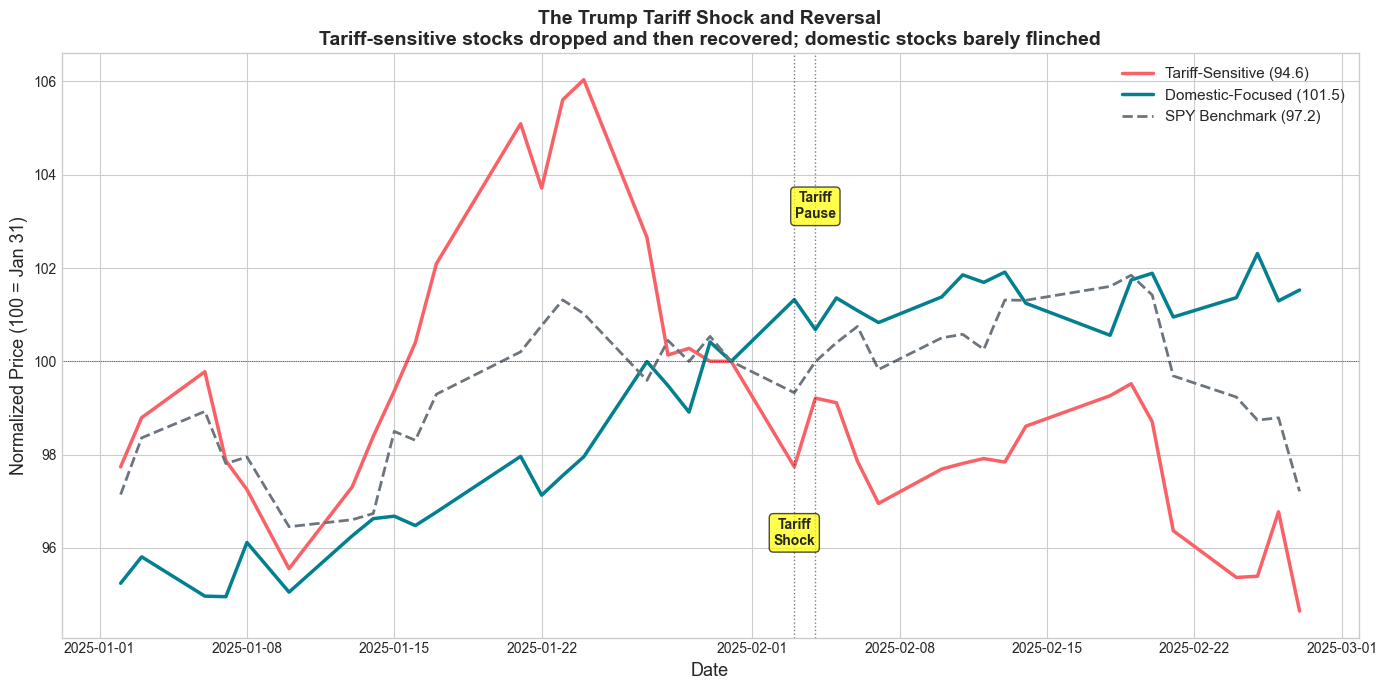

Key observation: The tariff-sensitive stocks moved much more than the market.
The domestic-focused stocks were relatively unaffected.
This is what we'd expect if markets correctly price tariff exposure.


In [5]:
# ============================================================
# NORMALIZED PRICE CHART: Tariff-Sensitive vs. Domestic
# ============================================================

# Normalize to Jan 31 = 100 (last trading day before event)
base_date = pd.Timestamp('2025-01-31')
# Find the closest trading day on or before base_date
available = close.index[close.index <= base_date]
if len(available) > 0:
    base_date = available[-1]

normalized = (close / close.loc[base_date]) * 100

# Create equal-weighted group baskets
tariff_basket = normalized[tariff_sensitive].mean(axis=1)
domestic_basket = normalized[domestic_focused].mean(axis=1)
spy_norm = normalized['SPY']

fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(tariff_basket.index, tariff_basket, color=CORAL, linewidth=2.5,
        label=f'Tariff-Sensitive ({tariff_basket.iloc[-1]:.1f})')
ax.plot(domestic_basket.index, domestic_basket, color=TEAL, linewidth=2.5,
        label=f'Domestic-Focused ({domestic_basket.iloc[-1]:.1f})')
ax.plot(spy_norm.index, spy_norm, color=GRAY, linewidth=2, linestyle='--',
        label=f'SPY Benchmark ({spy_norm.iloc[-1]:.1f})')

# Mark the event dates
for date_str, label, ypos in [('2025-02-03', 'Tariff\nShock', 96),
                                ('2025-02-04', 'Tariff\nPause', 103)]:
    date_ts = pd.Timestamp(date_str)
    if date_ts in spy_norm.index:
        ax.axvline(x=date_ts, color='black', linewidth=1, linestyle=':', alpha=0.5)
        ax.annotate(label, xy=(date_ts, ypos), fontsize=10, fontweight='bold',
                    ha='center', va='bottom',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.axhline(y=100, color='black', linewidth=0.5, linestyle=':')
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Normalized Price (100 = Jan 31)', fontsize=13)
ax.set_title('The Trump Tariff Shock and Reversal\n'
             'Tariff-sensitive stocks dropped and then recovered; domestic stocks barely flinched',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('Key observation: The tariff-sensitive stocks moved much more than the market.')
print('The domestic-focused stocks were relatively unaffected.')
print('This is what we\'d expect if markets correctly price tariff exposure.')

### 2c. Measuring Abnormal Returns

An **abnormal return** is the return *beyond* what we'd expect given how the overall market moved. From Week 2, recall that CAPM gives us:

$$R_{\text{stock}} = \alpha + \beta \times R_{\text{market}} + \epsilon$$

The **abnormal return** on a given day is:

$$AR_t = R_{\text{stock},t} - (\hat{\alpha} + \hat{\beta} \times R_{\text{market},t})$$

In other words: how much did the stock move *beyond* what its beta predicted?

Let's compute this for the tariff event days.

In [6]:
# ============================================================
# ABNORMAL RETURNS: Using CAPM regression
# ============================================================

# Step 1: Estimate beta using pre-event data (estimation window)
# Use returns from before the event to fit the model
pre_event = returns.loc[:'2025-01-30'].dropna()

# Step 2: Compute abnormal returns for each stock on event days
event_window = returns.loc['2025-02-03':'2025-02-07'].dropna()

print('Abnormal Returns (Event Window: Feb 3–7, 2025)')
print('=' * 75)
print(f'{"Stock":>6s}   {"Beta":>6s}  {"Feb 3":>8s}  {"Feb 4":>8s}  {"Feb 5":>8s}  {"Cumul. AR":>10s}')
print('-' * 75)

for group_name, tickers in [('TARIFF-SENSITIVE', tariff_sensitive), 
                              ('DOMESTIC-FOCUSED', domestic_focused)]:
    print(f'\n  --- {group_name} ---')
    for ticker in tickers:
        # Estimate beta from pre-event window
        stock_ret = pre_event[ticker].dropna()
        mkt_ret = pre_event['SPY'].loc[stock_ret.index]
        if len(stock_ret) < 10:
            continue
        slope, intercept, _, _, _ = stats.linregress(mkt_ret, stock_ret)
        
        # Compute abnormal returns in event window
        abnormal_returns = []
        for date in event_window.index[:3]:  # First 3 event days
            if ticker in returns.columns and date in returns.index:
                actual = returns.loc[date, ticker]
                expected = intercept + slope * returns.loc[date, 'SPY']
                ar = actual - expected
                abnormal_returns.append(ar)
            else:
                abnormal_returns.append(np.nan)
        
        cumulative_ar = np.nansum(abnormal_returns)
        ar_strs = [f'{ar:+.2%}' if not np.isnan(ar) else '   N/A' for ar in abnormal_returns]
        print(f'{ticker:>6s}   {slope:>6.2f}  {ar_strs[0]:>8s}  {ar_strs[1]:>8s}  {ar_strs[2]:>8s}  {cumulative_ar:>+9.2%}')

print('\n\nPositive AR = stock did better than its beta predicted (good news for that stock)')
print('Negative AR = stock did worse than its beta predicted (bad news for that stock)')

Abnormal Returns (Event Window: Feb 3–7, 2025)
 Stock     Beta     Feb 3     Feb 4     Feb 5   Cumul. AR
---------------------------------------------------------------------------

  --- TARIFF-SENSITIVE ---
    GM     0.47    -2.59%    +1.33%    -1.51%     -2.76%
     F     0.30    -1.92%    +2.28%    -1.84%     -1.48%
   CAT     0.96    -2.10%    -0.62%    -1.33%     -4.05%
    DE     0.22    -2.59%    +0.23%    -1.80%     -4.16%
  AVGO     3.25    +1.51%    +0.90%    +3.91%     +6.32%

  --- DOMESTIC-FOCUSED ---
   UNH     0.32    +0.87%    -1.11%    -1.56%     -1.80%
    VZ    -0.08    +1.43%    -0.39%    +0.82%     +1.86%
   DUK    -0.18    +0.69%    -0.83%    +1.08%     +0.94%
    WM    -0.04    +0.95%    -1.28%    +0.60%     +0.27%
   ADP     0.05    +1.21%    -1.14%    +0.87%     +0.93%


Positive AR = stock did better than its beta predicted (good news for that stock)
Negative AR = stock did worse than its beta predicted (bad news for that stock)


### 2d. The Speed of Market Adjustment

A key question for market efficiency: **how quickly did prices adjust?**

If markets are efficient, the adjustment should be nearly instantaneous — you shouldn't be able to profit by trading *after* the news is public.

Let's look at cumulative abnormal returns (CARs) over the event window to see if there was any "drift" (slow adjustment) or if it was all priced in immediately.

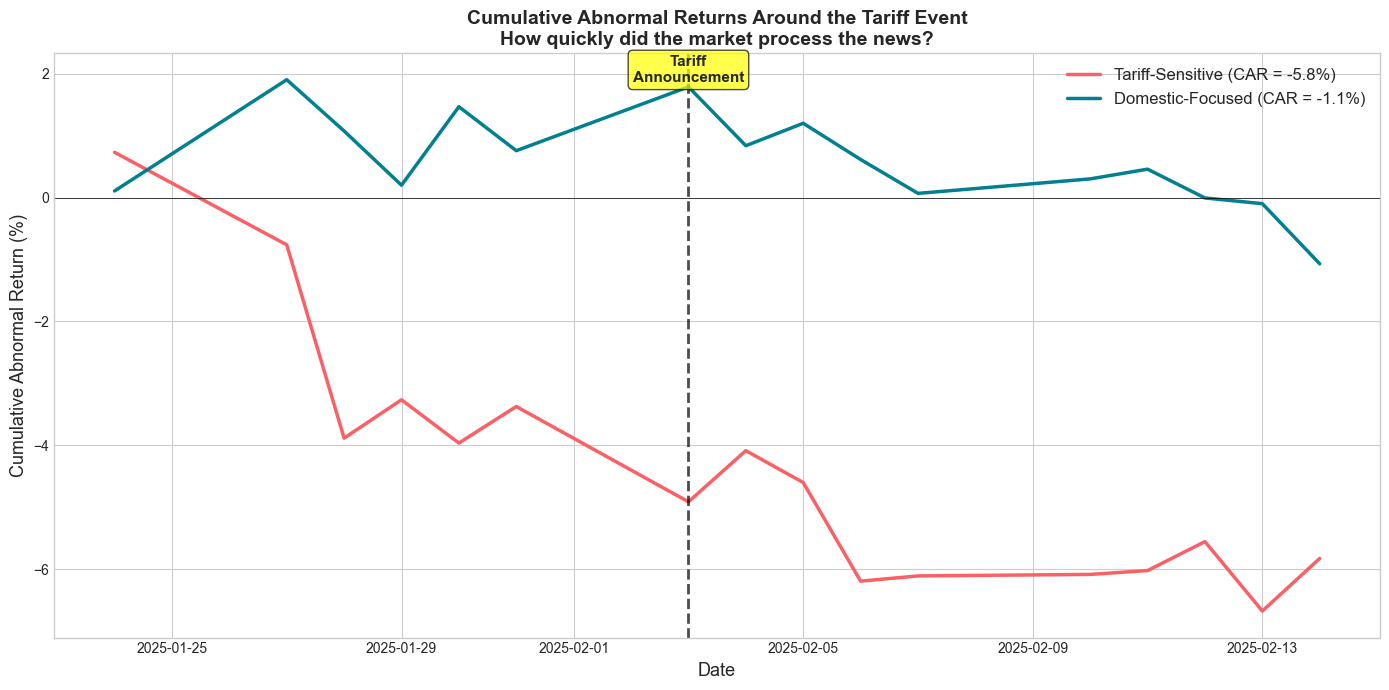

If markets are efficient, most of the price adjustment happens immediately.
Any post-announcement drift would suggest the market was slow to react.
Look at the chart: did prices keep moving after the event, or did they stabilize?


In [7]:
# ============================================================
# CUMULATIVE ABNORMAL RETURNS (CARs)
# ============================================================

# Compute CARs for the tariff-sensitive basket vs domestic basket
# Use a wider window: 5 days before to 10 days after
full_window = returns.loc['2025-01-24':'2025-02-14'].dropna()

fig, ax = plt.subplots(figsize=(14, 7))

for group_name, tickers, color in [('Tariff-Sensitive', tariff_sensitive, CORAL),
                                     ('Domestic-Focused', domestic_focused, TEAL)]:
    group_cars = []
    for ticker in tickers:
        stock_ret = pre_event[ticker].dropna()
        mkt_ret = pre_event['SPY'].loc[stock_ret.index]
        if len(stock_ret) < 10:
            continue
        slope, intercept, _, _, _ = stats.linregress(mkt_ret, stock_ret)
        
        # Abnormal returns over full window
        ars = []
        for date in full_window.index:
            actual = returns.loc[date, ticker]
            expected = intercept + slope * returns.loc[date, 'SPY']
            ars.append(actual - expected)
        group_cars.append(ars)
    
    # Average CARs across stocks in the group
    avg_cars = np.cumsum(np.nanmean(group_cars, axis=0)) * 100
    ax.plot(full_window.index, avg_cars, color=color, linewidth=2.5,
            label=f'{group_name} (CAR = {avg_cars[-1]:+.1f}%)')

# Mark event
event_ts = pd.Timestamp('2025-02-03')
if event_ts in full_window.index:
    ax.axvline(x=event_ts, color='black', linewidth=2, linestyle='--', alpha=0.7)
    ax.annotate('Tariff\nAnnouncement', xy=(event_ts, ax.get_ylim()[1] * 0.8),
                fontsize=11, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_xlabel('Date', fontsize=13)
ax.set_ylabel('Cumulative Abnormal Return (%)', fontsize=13)
ax.set_title('Cumulative Abnormal Returns Around the Tariff Event\n'
             'How quickly did the market process the news?',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print('If markets are efficient, most of the price adjustment happens immediately.')
print('Any post-announcement drift would suggest the market was slow to react.')
print('Look at the chart: did prices keep moving after the event, or did they stabilize?')

**Pause and reflect:**
- Did the tariff-sensitive stocks show a clear negative reaction on Feb 3?
- How quickly did the reversal happen when the tariff pause was announced?
- Could you have profited by trading *after* the news was public? (What does this say about EMH?)

---

### 2e. Trading the News with Options — Puts, Calls, and the Tariff Event

In Week 2, you learned about **options** — contracts that give you the right (not obligation) to buy or sell a stock at a specific price. Let's see how a trader could have used options around the tariff event.

**Quick recap:**
- **Put option**: Right to **sell** at the strike price → profits when stock **falls** (downside bet / insurance)
- **Call option**: Right to **buy** at the strike price → profits when stock **rises** (upside bet)

### Why options for news events?

Options are powerful tools for trading around anticipated events because:
1. **Leverage**: A small premium controls a large position (amplifies gains *and* losses)
2. **Defined risk**: Max loss = the premium you paid (unlike shorting, where losses are theoretically unlimited)
3. **Asymmetry**: You can bet on a big move in one direction while capping your downside

### Three option strategies a trader might have used around the tariff announcement:

GM Price Timeline:
  Jan 31 (pre-event):    $48.95
  Feb 3 (tariff shock):  $47.41 (-3.2%)
  Feb 4 (tariff pause):  $48.07 (-1.8%)


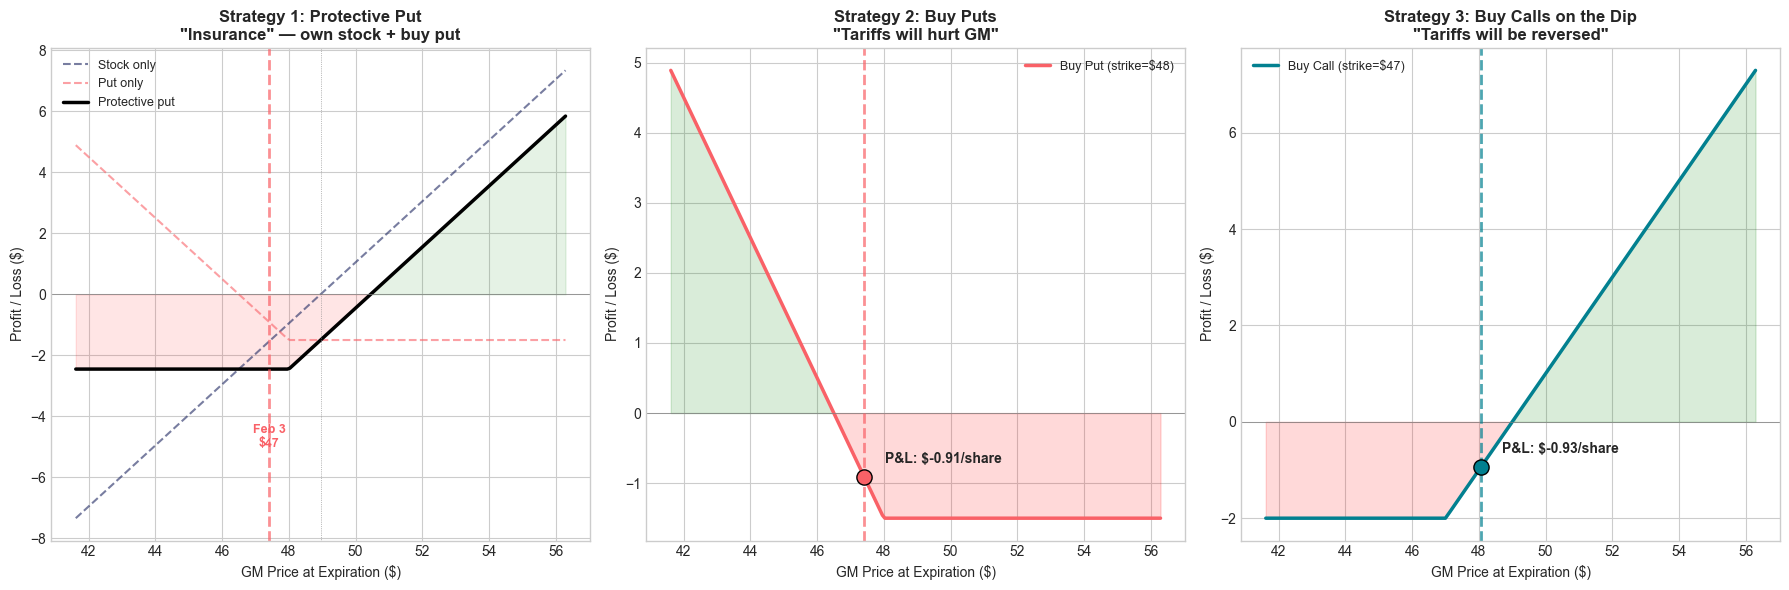

Three ways options could have been used around the tariff event:
  1. PROTECTIVE PUT: Own GM + buy $48 put for $1.5
     → Limits downside if tariffs tank the stock, keeps upside if they don't
     → Cost: $1.5 per share in premium (the price of insurance)
  2. BUY PUTS (bearish): Bet GM will fall below $46.50
     → Max loss = $1.5 (the premium). Max gain = $46.50 (if GM → $0)
  3. BUY CALLS ON THE DIP: After Feb 3 crash, bet on a reversal
     → Max loss = $2.0 (the premium). Profits if GM rebounds above $49.00


In [8]:
# ============================================================
# OPTION STRATEGIES FOR THE TARIFF EVENT
# ============================================================

# Let's use GM (General Motors) as our example — heavily exposed to Mexico/Canada tariffs.
# We'll look at the actual GM prices around the tariff event.

gm_pre_event_price = close['GM'].loc[:pd.Timestamp('2025-01-31')].iloc[-1]
gm_post_shock = close['GM'].loc[pd.Timestamp('2025-02-03'):].iloc[0]  # Feb 3 close
gm_post_reversal = close['GM'].loc[pd.Timestamp('2025-02-04'):].iloc[0]  # Feb 4 close

print(f'GM Price Timeline:')
print(f'  Jan 31 (pre-event):    ${gm_pre_event_price:.2f}')
print(f'  Feb 3 (tariff shock):  ${gm_post_shock:.2f} ({(gm_post_shock/gm_pre_event_price - 1)*100:+.1f}%)')
print(f'  Feb 4 (tariff pause):  ${gm_post_reversal:.2f} ({(gm_post_reversal/gm_pre_event_price - 1)*100:+.1f}%)')

# ============================================================
# Three option strategies around the tariff event
# ============================================================

strike_put = round(gm_pre_event_price * 0.98)  # ~2% out-of-the-money put
put_premium = 1.50

# Range of possible GM prices
prices_range = np.linspace(gm_pre_event_price * 0.85, gm_pre_event_price * 1.15, 200)

# Stock P&L (from owning shares)
stock_pnl = prices_range - gm_pre_event_price
put_pnl = np.maximum(strike_put - prices_range, 0) - put_premium
protective_put_pnl = stock_pnl + put_pnl

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Strategy 1: Protective Put (insurance against crash) ---
ax = axes[0]
ax.plot(prices_range, stock_pnl, '--', color=NAVY, linewidth=1.5, alpha=0.6, label='Stock only')
ax.plot(prices_range, put_pnl, '--', color=CORAL, linewidth=1.5, alpha=0.6, label='Put only')
ax.plot(prices_range, protective_put_pnl, color='black', linewidth=2.5, label='Protective put')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=gm_pre_event_price, color='gray', linewidth=0.5, linestyle=':')
ax.fill_between(prices_range, protective_put_pnl, 0,
                where=(protective_put_pnl > 0), alpha=0.1, color='green')
ax.fill_between(prices_range, protective_put_pnl, 0,
                where=(protective_put_pnl < 0), alpha=0.1, color='red')
# Mark Feb 3 crash price
ax.axvline(x=gm_post_shock, color=CORAL, linewidth=2, linestyle='--', alpha=0.7)
ax.annotate(f'Feb 3\n${gm_post_shock:.0f}', xy=(gm_post_shock, -5),
            fontsize=9, fontweight='bold', color=CORAL, ha='center')
ax.set_xlabel('GM Price at Expiration ($)')
ax.set_ylabel('Profit / Loss ($)')
ax.set_title('Strategy 1: Protective Put\n"Insurance" — own stock + buy put',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)

# --- Strategy 2: Buy Puts (bearish bet on tariffs) ---
ax = axes[1]
ax.plot(prices_range, put_pnl, color=CORAL, linewidth=2.5, label=f'Buy Put (strike=${strike_put})')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.fill_between(prices_range, put_pnl, 0,
                where=(put_pnl > 0), alpha=0.15, color='green')
ax.fill_between(prices_range, put_pnl, 0,
                where=(put_pnl < 0), alpha=0.15, color='red')
ax.axvline(x=gm_post_shock, color=CORAL, linewidth=2, linestyle='--', alpha=0.7)
# Show actual P&L at the Feb 3 price
pnl_at_shock = max(strike_put - gm_post_shock, 0) - put_premium
ax.scatter([gm_post_shock], [pnl_at_shock], s=120, color=CORAL, edgecolor='black', zorder=5)
ax.annotate(f'P&L: ${pnl_at_shock:+.2f}/share', xy=(gm_post_shock, pnl_at_shock),
            textcoords='offset points', xytext=(15, 10), fontsize=10, fontweight='bold')
ax.set_xlabel('GM Price at Expiration ($)')
ax.set_ylabel('Profit / Loss ($)')
ax.set_title('Strategy 2: Buy Puts\n"Tariffs will hurt GM"',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)

# --- Strategy 3: Buy Calls on the dip (bet on reversal) ---
ax = axes[2]
strike_call = round(gm_post_shock)  # At-the-money call bought after the crash
call_premium = 2.00
call_pnl = np.maximum(prices_range - strike_call, 0) - call_premium

ax.plot(prices_range, call_pnl, color=TEAL, linewidth=2.5,
        label=f'Buy Call (strike=${strike_call})')
ax.axhline(y=0, color='gray', linewidth=0.5)
ax.fill_between(prices_range, call_pnl, 0,
                where=(call_pnl > 0), alpha=0.15, color='green')
ax.fill_between(prices_range, call_pnl, 0,
                where=(call_pnl < 0), alpha=0.15, color='red')
ax.axvline(x=gm_post_reversal, color=TEAL, linewidth=2, linestyle='--', alpha=0.7)
# Show actual P&L at the Feb 4 reversal price
pnl_at_reversal = max(gm_post_reversal - strike_call, 0) - call_premium
ax.scatter([gm_post_reversal], [pnl_at_reversal], s=120, color=TEAL, edgecolor='black', zorder=5)
ax.annotate(f'P&L: ${pnl_at_reversal:+.2f}/share', xy=(gm_post_reversal, pnl_at_reversal),
            textcoords='offset points', xytext=(15, 10), fontsize=10, fontweight='bold')
ax.set_xlabel('GM Price at Expiration ($)')
ax.set_ylabel('Profit / Loss ($)')
ax.set_title('Strategy 3: Buy Calls on the Dip\n"Tariffs will be reversed"',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

print('Three ways options could have been used around the tariff event:')
print(f'  1. PROTECTIVE PUT: Own GM + buy ${strike_put} put for ${put_premium}')
print(f'     → Limits downside if tariffs tank the stock, keeps upside if they don\'t')
print(f'     → Cost: ${put_premium} per share in premium (the price of insurance)')
print(f'  2. BUY PUTS (bearish): Bet GM will fall below ${strike_put - put_premium:.2f}')
print(f'     → Max loss = ${put_premium} (the premium). Max gain = ${strike_put - put_premium:.2f} (if GM → $0)')
print(f'  3. BUY CALLS ON THE DIP: After Feb 3 crash, bet on a reversal')
print(f'     → Max loss = ${call_premium} (the premium). Profits if GM rebounds above ${strike_call + call_premium:.2f}')

### Options Takeaways for Event-Driven Trading

**Key insight:** Options let you express a *view* on news events with **defined risk**.

| If you think... | Strategy | Max Loss | Potential Gain |
|----------------|----------|----------|----------------|
| "Tariffs will hurt GM" | Buy puts | Premium paid | Large if stock crashes |
| "I own GM and want insurance" | Protective put (stock + put) | Premium paid | Unlimited upside minus premium |
| "The crash is overdone, it'll reverse" | Buy calls after the dip | Premium paid | Large if stock rebounds |
| "Big move coming, unsure of direction" | Straddle (buy call + put) | Both premiums | Large if stock moves a lot either way |

**The EMH connection:** If markets are efficient, option prices *already reflect* the probability of tariff scenarios. The put premium you'd pay on Jan 31 would be high precisely because the market knows tariff risk exists. This is **implied volatility** — the market's estimate of how much a stock might move.

**The practical challenge:** You can't consistently buy "cheap" options before news events because the options market is pricing in the same information you have. This is the options market's version of market efficiency.

---

## Part 3: RSI Analysis — Tech vs. Consumer Durables

### What is RSI and Why Do Traders Use It?

The **Relative Strength Index (RSI)** is one of the most popular **momentum oscillators** in technical analysis. It was developed by J. Welles Wilder in 1978, and virtually every trading platform displays it.

RSI measures the **speed and magnitude of recent price changes** on a scale of 0 to 100. The intuition is simple:

| RSI Range | Name | What It Means | Trader Interpretation |
|-----------|------|---------------|----------------------|
| **> 70** | Overbought | Price has risen fast relative to recent history | Stock may be "due for a pullback" — too many buyers, exhaustion |
| **30–70** | Neutral | Normal trading range | No strong signal |
| **< 30** | Oversold | Price has fallen fast relative to recent history | Stock may be "due for a bounce" — selling overdone |

### How RSI is calculated (step by step):

1. **Daily price changes**: How much did the stock go up or down each day?
2. **Separate gains and losses**: Keep gains positive, losses positive (absolute value)
3. **Average gain / Average loss** over a 14-day rolling window = **RS** (Relative Strength)
4. **RSI = 100 - (100 / (1 + RS))**

When gains dominate → RS is high → RSI approaches 100 (overbought)  
When losses dominate → RS is low → RSI approaches 0 (oversold)

### The Big Question (connects to Week 3):

If markets are efficient, RSI shouldn't predict future returns — the information is already priced in. But traders use it anyway. Is RSI a useful signal, or just noise? Let's look at the data.

Let's compare RSI patterns for **tech/SaaS stocks** vs. **consumer durables/staples** — two sectors that have behaved very differently recently.

In [9]:
# ============================================================
# DOWNLOAD DATA: Tech/SaaS vs. Consumer Durables
# ============================================================

# Tech / SaaS stocks (high-growth, high-multiple names)
tech_tickers = ['MSFT', 'NVDA', 'CRM', 'ADBE', 'NOW', 'AAPL']

# Consumer durables / staples ("boring" stocks)
durables_tickers = ['WMT', 'PG', 'KO', 'JNJ', 'HD', 'MCD']

all_sector_tickers = tech_tickers + durables_tickers

# Download 1 year of data
sector_data = yf.download(all_sector_tickers, period='1y')
sector_close = sector_data['Close']

print(f'Downloaded {len(sector_close)} trading days')
print(f'\nTech/SaaS: {tech_tickers}')
print(f'Consumer Durables/Staples: {durables_tickers}')

[*********************100%***********************]  12 of 12 completed

Downloaded 251 trading days

Tech/SaaS: ['MSFT', 'NVDA', 'CRM', 'ADBE', 'NOW', 'AAPL']
Consumer Durables/Staples: ['WMT', 'PG', 'KO', 'JNJ', 'HD', 'MCD']


In [10]:
# ============================================================
# RSI COMPUTATION
# ============================================================

def compute_rsi(prices, window=14):
    """Compute the Relative Strength Index from a price series."""
    delta = prices.diff()
    gain = delta.where(delta > 0, 0).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

# Compute RSI for all stocks
rsi_data = pd.DataFrame()
for ticker in all_sector_tickers:
    rsi_data[ticker] = compute_rsi(sector_close[ticker])

# Show current RSI values
print('Current RSI Values (most recent trading day)')
print('=' * 50)
print(f'\n  Tech/SaaS:')
for t in tech_tickers:
    rsi_val = rsi_data[t].iloc[-1]
    status = 'OVERBOUGHT' if rsi_val > 70 else ('OVERSOLD' if rsi_val < 30 else 'neutral')
    print(f'    {t:6s}: RSI = {rsi_val:5.1f}  ({status})')

print(f'\n  Consumer Durables/Staples:')
for t in durables_tickers:
    rsi_val = rsi_data[t].iloc[-1]
    status = 'OVERBOUGHT' if rsi_val > 70 else ('OVERSOLD' if rsi_val < 30 else 'neutral')
    print(f'    {t:6s}: RSI = {rsi_val:5.1f}  ({status})')

Current RSI Values (most recent trading day)

  Tech/SaaS:
    MSFT  : RSI =  43.0  (neutral)
    NVDA  : RSI =  74.5  (OVERBOUGHT)
    CRM   : RSI =  43.5  (neutral)
    ADBE  : RSI =  32.7  (neutral)
    NOW   : RSI =  41.9  (neutral)
    AAPL  : RSI =  48.2  (neutral)

  Consumer Durables/Staples:
    WMT   : RSI =  46.6  (neutral)
    PG    : RSI =  64.4  (neutral)
    KO    : RSI =  65.6  (neutral)
    JNJ   : RSI =  70.8  (OVERBOUGHT)
    HD    : RSI =  40.5  (neutral)
    MCD   : RSI =  64.5  (neutral)


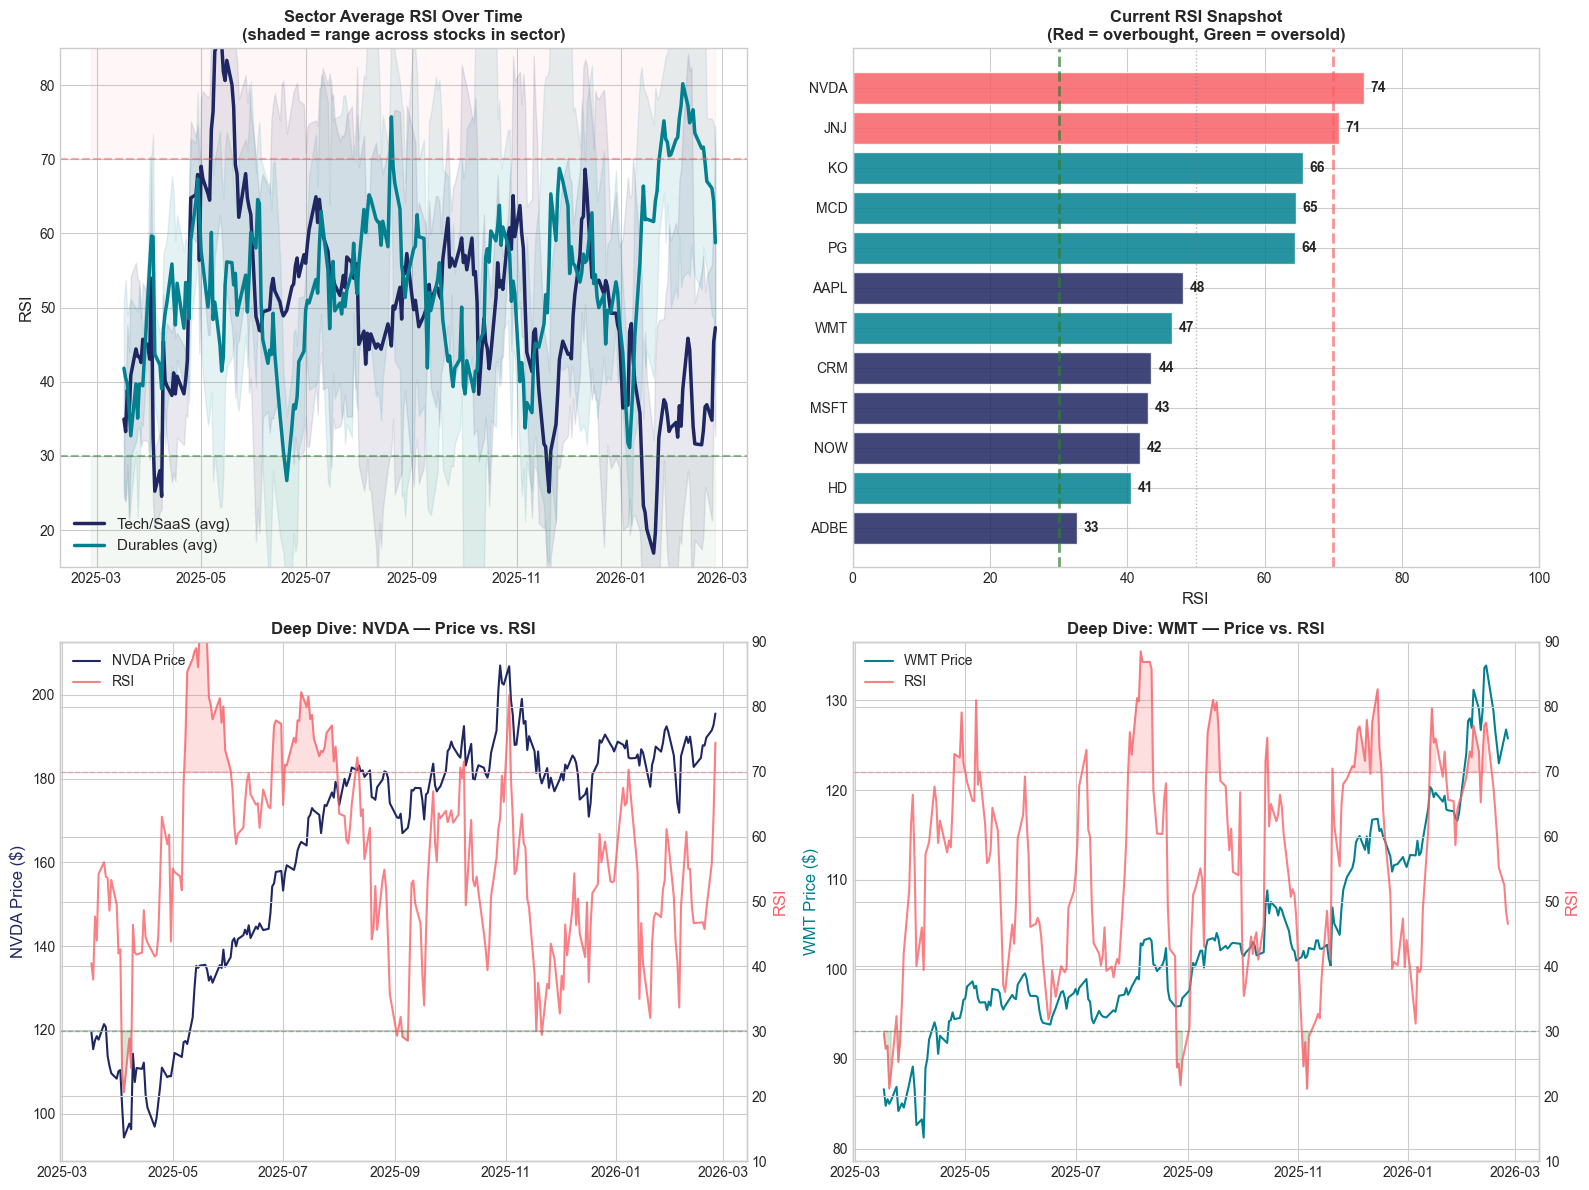

Reading the charts:
• Top-left: Sector RSI averages — the shaded bands show how much individual stocks vary
• Top-right: Snapshot of where each stock sits RIGHT NOW on the RSI scale
• Bottom: Price overlaid with RSI — notice how RSI extremes often (but not always!) 
  correspond to local price peaks and troughs

Key question: Does RSI hitting 30 reliably predict a bounce? (Hint: think about EMH)


In [11]:
# ============================================================
# RSI VISUALIZATION: Sector Average with Range + Current Snapshot
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# --- Top Left: Sector Average RSI Over Time (with min/max range) ---
ax = axes[0, 0]
# Tech sector
tech_rsi_mean = rsi_data[tech_tickers].mean(axis=1)
tech_rsi_min = rsi_data[tech_tickers].min(axis=1)
tech_rsi_max = rsi_data[tech_tickers].max(axis=1)
ax.plot(tech_rsi_mean.index, tech_rsi_mean, color=NAVY, linewidth=2.5, label='Tech/SaaS (avg)')
ax.fill_between(tech_rsi_mean.index, tech_rsi_min, tech_rsi_max, color=NAVY, alpha=0.1)

# Durables sector
dur_rsi_mean = rsi_data[durables_tickers].mean(axis=1)
dur_rsi_min = rsi_data[durables_tickers].min(axis=1)
dur_rsi_max = rsi_data[durables_tickers].max(axis=1)
ax.plot(dur_rsi_mean.index, dur_rsi_mean, color=TEAL, linewidth=2.5, label='Durables (avg)')
ax.fill_between(dur_rsi_mean.index, dur_rsi_min, dur_rsi_max, color=TEAL, alpha=0.1)

ax.axhline(y=70, color=CORAL, linewidth=1.5, linestyle='--', alpha=0.5)
ax.axhline(y=30, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.5)
ax.fill_between(tech_rsi_mean.index, 70, 85, alpha=0.05, color=CORAL)
ax.fill_between(tech_rsi_mean.index, 15, 30, alpha=0.05, color=GREEN)
ax.set_ylim(15, 85)
ax.set_ylabel('RSI', fontsize=12)
ax.set_title('Sector Average RSI Over Time\n(shaded = range across stocks in sector)', fontweight='bold')
ax.legend(fontsize=11)

# --- Top Right: Current RSI Snapshot (bar chart) ---
ax = axes[0, 1]
current_rsi = rsi_data.iloc[-1][all_sector_tickers].sort_values(ascending=True)
colors_bar = []
for t in current_rsi.index:
    rsi_val = current_rsi[t]
    if rsi_val > 70:
        colors_bar.append(CORAL)   # Overbought
    elif rsi_val < 30:
        colors_bar.append(GREEN)   # Oversold
    elif t in tech_tickers:
        colors_bar.append(NAVY)    # Tech, neutral
    else:
        colors_bar.append(TEAL)    # Durables, neutral

bars = ax.barh(current_rsi.index, current_rsi.values, color=colors_bar, alpha=0.85,
               edgecolor='white')
ax.axvline(x=70, color=CORAL, linewidth=2, linestyle='--', alpha=0.7)
ax.axvline(x=30, color=GREEN, linewidth=2, linestyle='--', alpha=0.7)
ax.axvline(x=50, color=GRAY, linewidth=1, linestyle=':', alpha=0.5)

# Value labels
for bar, val in zip(bars, current_rsi.values):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            f'{val:.0f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('RSI', fontsize=12)
ax.set_title('Current RSI Snapshot\n(Red = overbought, Green = oversold)', fontweight='bold')
ax.set_xlim(0, 100)

# --- Bottom Left: RSI for one example tech stock ---
ax = axes[1, 0]
example_tech = 'NVDA'
rsi_ex = rsi_data[example_tech].dropna()
price_ex = sector_close[example_tech].loc[rsi_ex.index]

# Twin axis: price on left, RSI on right
ax.plot(price_ex.index, price_ex, color=NAVY, linewidth=1.5, label=f'{example_tech} Price')
ax.set_ylabel(f'{example_tech} Price ($)', fontsize=12, color=NAVY)
ax.set_title(f'Deep Dive: {example_tech} — Price vs. RSI', fontweight='bold')

ax2 = ax.twinx()
ax2.plot(rsi_ex.index, rsi_ex, color=CORAL, linewidth=1.5, alpha=0.8, label='RSI')
ax2.axhline(y=70, color=CORAL, linewidth=1, linestyle='--', alpha=0.4)
ax2.axhline(y=30, color=GREEN, linewidth=1, linestyle='--', alpha=0.4)
ax2.set_ylabel('RSI', fontsize=12, color=CORAL)
ax2.set_ylim(10, 90)

# Shade overbought/oversold periods
ax2.fill_between(rsi_ex.index, 70, rsi_ex.where(rsi_ex > 70), alpha=0.2, color=CORAL)
ax2.fill_between(rsi_ex.index, 30, rsi_ex.where(rsi_ex < 30), alpha=0.2, color=GREEN)

# Combined legend
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

# --- Bottom Right: RSI for one example durables stock ---
ax = axes[1, 1]
example_dur = 'WMT'
rsi_ex2 = rsi_data[example_dur].dropna()
price_ex2 = sector_close[example_dur].loc[rsi_ex2.index]

ax.plot(price_ex2.index, price_ex2, color=TEAL, linewidth=1.5, label=f'{example_dur} Price')
ax.set_ylabel(f'{example_dur} Price ($)', fontsize=12, color=TEAL)
ax.set_title(f'Deep Dive: {example_dur} — Price vs. RSI', fontweight='bold')

ax3 = ax.twinx()
ax3.plot(rsi_ex2.index, rsi_ex2, color=CORAL, linewidth=1.5, alpha=0.8, label='RSI')
ax3.axhline(y=70, color=CORAL, linewidth=1, linestyle='--', alpha=0.4)
ax3.axhline(y=30, color=GREEN, linewidth=1, linestyle='--', alpha=0.4)
ax3.set_ylabel('RSI', fontsize=12, color=CORAL)
ax3.set_ylim(10, 90)

ax3.fill_between(rsi_ex2.index, 70, rsi_ex2.where(rsi_ex2 > 70), alpha=0.2, color=CORAL)
ax3.fill_between(rsi_ex2.index, 30, rsi_ex2.where(rsi_ex2 < 30), alpha=0.2, color=GREEN)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

print('Reading the charts:')
print('• Top-left: Sector RSI averages — the shaded bands show how much individual stocks vary')
print('• Top-right: Snapshot of where each stock sits RIGHT NOW on the RSI scale')
print('• Bottom: Price overlaid with RSI — notice how RSI extremes often (but not always!) ')
print('  correspond to local price peaks and troughs')
print('\nKey question: Does RSI hitting 30 reliably predict a bounce? (Hint: think about EMH)')

In [12]:
# ============================================================
# RSI SUMMARY STATISTICS: Compare the two sectors
# ============================================================

print('RSI Summary Statistics')
print('=' * 65)
print(f'{"Stock":>6s}  {"Mean":>6s}  {"Std":>6s}  {"Min":>6s}  {"Max":>6s}  {"Days>70":>7s}  {"Days<30":>7s}')
print('-' * 65)

for group_name, tickers in [('TECH', tech_tickers), ('DURABLES', durables_tickers)]:
    print(f'  --- {group_name} ---')
    for t in tickers:
        rsi = rsi_data[t].dropna()
        overbought = (rsi > 70).sum()
        oversold = (rsi < 30).sum()
        print(f'{t:>6s}  {rsi.mean():>6.1f}  {rsi.std():>6.1f}  {rsi.min():>6.1f}  '
              f'{rsi.max():>6.1f}  {overbought:>7d}  {oversold:>7d}')

# Sector averages
tech_mean_rsi = rsi_data[tech_tickers].mean().mean()
dur_mean_rsi = rsi_data[durables_tickers].mean().mean()
print(f'\nSector Average RSI:')
print(f'  Tech/SaaS:         {tech_mean_rsi:.1f}')
print(f'  Consumer Durables: {dur_mean_rsi:.1f}')

RSI Summary Statistics
 Stock    Mean     Std     Min     Max  Days>70  Days<30
-----------------------------------------------------------------
  --- TECH ---
  MSFT    53.1    17.9    18.2    96.0       44       26
  NVDA    56.7    14.7    20.6    92.7       48        8
   CRM    45.5    17.4    13.1    85.8       24       47
  ADBE    44.5    19.2     9.6    96.2       29       56
   NOW    44.2    16.5     8.2    90.4       19       46
  AAPL    52.9    17.4     6.5    84.2       41       23
  --- DURABLES ---
   WMT    55.6    16.0    21.2    88.5       49       15
    PG    48.6    14.6    21.7    85.1       32       14
    KO    52.0    14.2    19.3    90.9       31       14
   JNJ    61.8    18.6    25.5    98.2       84        4
    HD    50.3    17.0     6.2    82.4       34       30
   MCD    52.2    15.1    10.6    88.0       26       20

Sector Average RSI:
  Tech/SaaS:         49.5
  Consumer Durables: 53.4


---

## Part 4: PE Ratios — The SaaS Decline and the Rise of "Boring" Stocks

One of the big stories in markets over the past year has been a **valuation rotation**:

- **SaaS / high-growth tech** stocks have seen their PE ratios compress — investors are less willing to pay a premium for growth after interest rates rose
- **"Boring" consumer staples and durables** stocks have seen their PEs *increase* — investors rotated into safer, dividend-paying names

This is a classic **growth-to-value rotation**. Let's visualize it.

### Why PE Ratios Matter

The **Price-to-Earnings ratio** tells you how much investors pay per dollar of earnings:

$$PE = \frac{\text{Stock Price}}{\text{Earnings Per Share}}$$

- **High PE** → investors expect strong future growth (or the stock is overvalued)
- **Low PE** → investors expect slow growth (or the stock is undervalued)

In [13]:
# ============================================================
# DOWNLOAD PE RATIOS AND KEY METRICS
# ============================================================

metrics = []

for ticker in all_sector_tickers:
    try:
        info = yf.Ticker(ticker).info
        pe = info.get('trailingPE', None)
        fwd_pe = info.get('forwardPE', None)
        div_yield = info.get('dividendYield', 0)
        mkt_cap = info.get('marketCap', None)
        sector = 'Tech/SaaS' if ticker in tech_tickers else 'Consumer Durables/Staples'
        
        metrics.append({
            'Ticker': ticker,
            'Sector': sector,
            'Trailing PE': pe,
            'Forward PE': fwd_pe,
            'Div Yield': div_yield if div_yield else 0,
            'Mkt Cap ($B)': mkt_cap / 1e9 if mkt_cap else None
        })
        pe_str = f'{pe:.1f}' if pe else 'N/A'
        fwd_str = f'{fwd_pe:.1f}' if fwd_pe else 'N/A'
        print(f'  {ticker:6s}: Trailing PE = {pe_str:>6s}, Forward PE = {fwd_str:>6s}')
    except Exception as e:
        print(f'  {ticker}: Error — {e}')

metrics_df = pd.DataFrame(metrics).dropna(subset=['Trailing PE'])
print(f'\nSuccessfully retrieved metrics for {len(metrics_df)} stocks')

  MSFT  : Trailing PE =   25.1, Forward PE =   21.3
  NVDA  : Trailing PE =   48.3, Forward PE =   19.1
  CRM   : Trailing PE =   25.6, Forward PE =   12.9
  ADBE  : Trailing PE =   15.4, Forward PE =    9.8
  NOW   : Trailing PE =   62.4, Forward PE =   20.8
  AAPL  : Trailing PE =   34.7, Forward PE =   29.5
  WMT   : Trailing PE =   46.1, Forward PE =   38.2
  PG    : Trailing PE =   24.2, Forward PE =   22.3
  KO    : Trailing PE =   26.5, Forward PE =   23.2
  JNJ   : Trailing PE =   22.2, Forward PE =   19.5
  HD    : Trailing PE =   26.4, Forward PE =   23.0
  MCD   : Trailing PE =   27.8, Forward PE =   23.3

Successfully retrieved metrics for 12 stocks


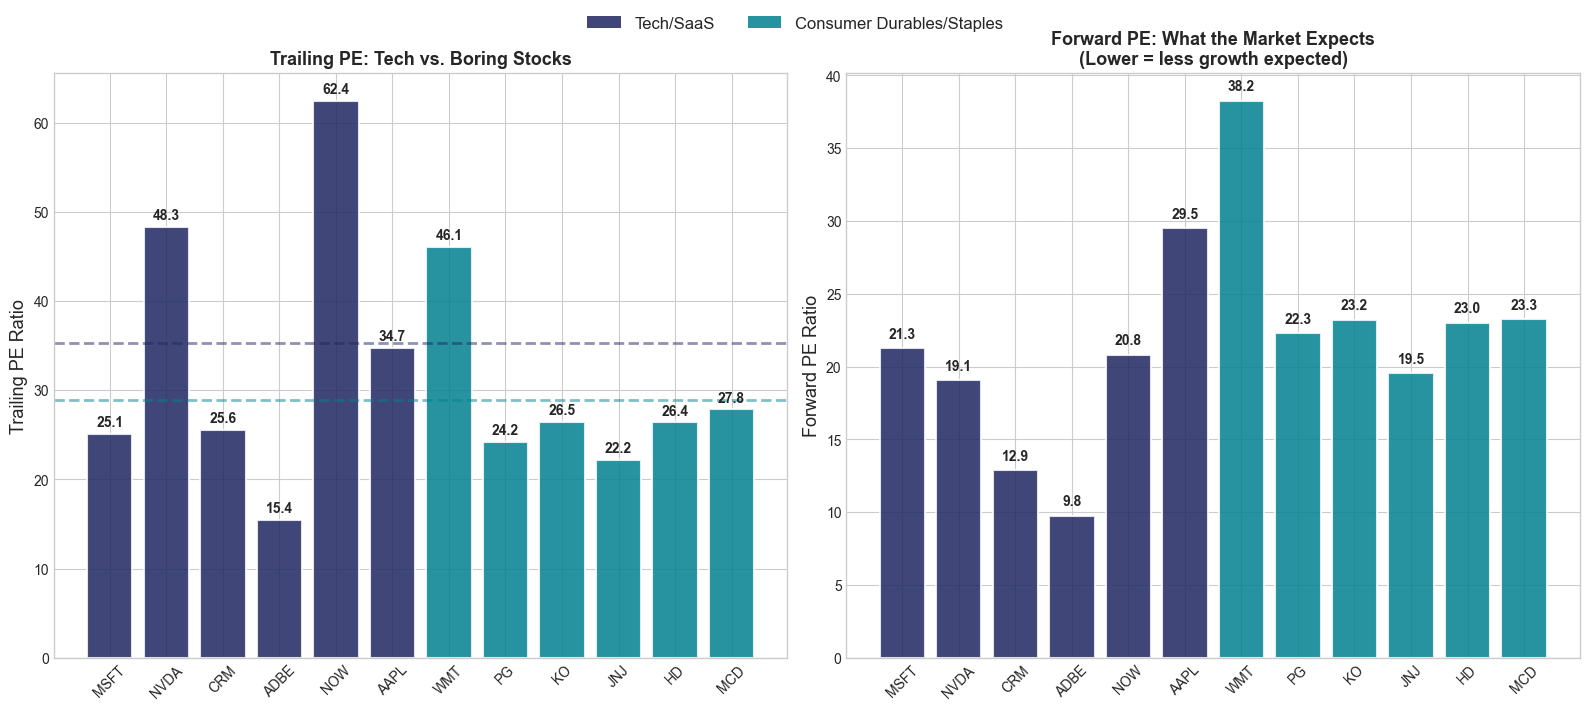

Tech/SaaS average trailing PE: 35.2
Consumer Durables avg trailing PE: 28.9
Tech PE premium: 1.2x

Key question: Is the tech premium justified by faster earnings growth?
Or have investors overpaid for growth that's decelerating?


In [14]:
# ============================================================
# PE RATIO COMPARISON: Bar Chart
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# --- Left: Trailing PE ---
ax = axes[0]
colors_pe = [NAVY if t in tech_tickers else TEAL for t in metrics_df['Ticker']]
bars = ax.bar(metrics_df['Ticker'], metrics_df['Trailing PE'], color=colors_pe,
              alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, pe_val in zip(bars, metrics_df['Trailing PE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pe_val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

tech_avg_pe = metrics_df[metrics_df['Sector'] == 'Tech/SaaS']['Trailing PE'].mean()
dur_avg_pe = metrics_df[metrics_df['Sector'] == 'Consumer Durables/Staples']['Trailing PE'].mean()
ax.axhline(y=tech_avg_pe, color=NAVY, linewidth=2, linestyle='--', alpha=0.5)
ax.axhline(y=dur_avg_pe, color=TEAL, linewidth=2, linestyle='--', alpha=0.5)

ax.set_ylabel('Trailing PE Ratio', fontsize=13)
ax.set_title('Trailing PE: Tech vs. Boring Stocks', fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=45)

# --- Right: Forward PE (expectations) ---
ax = axes[1]
fwd_df = metrics_df.dropna(subset=['Forward PE'])
colors_fwd = [NAVY if t in tech_tickers else TEAL for t in fwd_df['Ticker']]
bars = ax.bar(fwd_df['Ticker'], fwd_df['Forward PE'], color=colors_fwd,
              alpha=0.85, edgecolor='white', linewidth=1.5)

for bar, pe_val in zip(bars, fwd_df['Forward PE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{pe_val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Forward PE Ratio', fontsize=13)
ax.set_title('Forward PE: What the Market Expects\n(Lower = less growth expected)',
             fontweight='bold', fontsize=13)
ax.tick_params(axis='x', rotation=45)

# Shared legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=NAVY, alpha=0.85, label='Tech/SaaS'),
                   Patch(facecolor=TEAL, alpha=0.85, label='Consumer Durables/Staples')]
fig.legend(handles=legend_elements, fontsize=12, loc='upper center',
           bbox_to_anchor=(0.5, 1.02), ncol=2)

plt.tight_layout()
plt.show()

print(f'Tech/SaaS average trailing PE: {tech_avg_pe:.1f}')
print(f'Consumer Durables avg trailing PE: {dur_avg_pe:.1f}')
print(f'Tech PE premium: {tech_avg_pe/dur_avg_pe:.1f}x')
print(f'\nKey question: Is the tech premium justified by faster earnings growth?')
print('Or have investors overpaid for growth that\'s decelerating?')

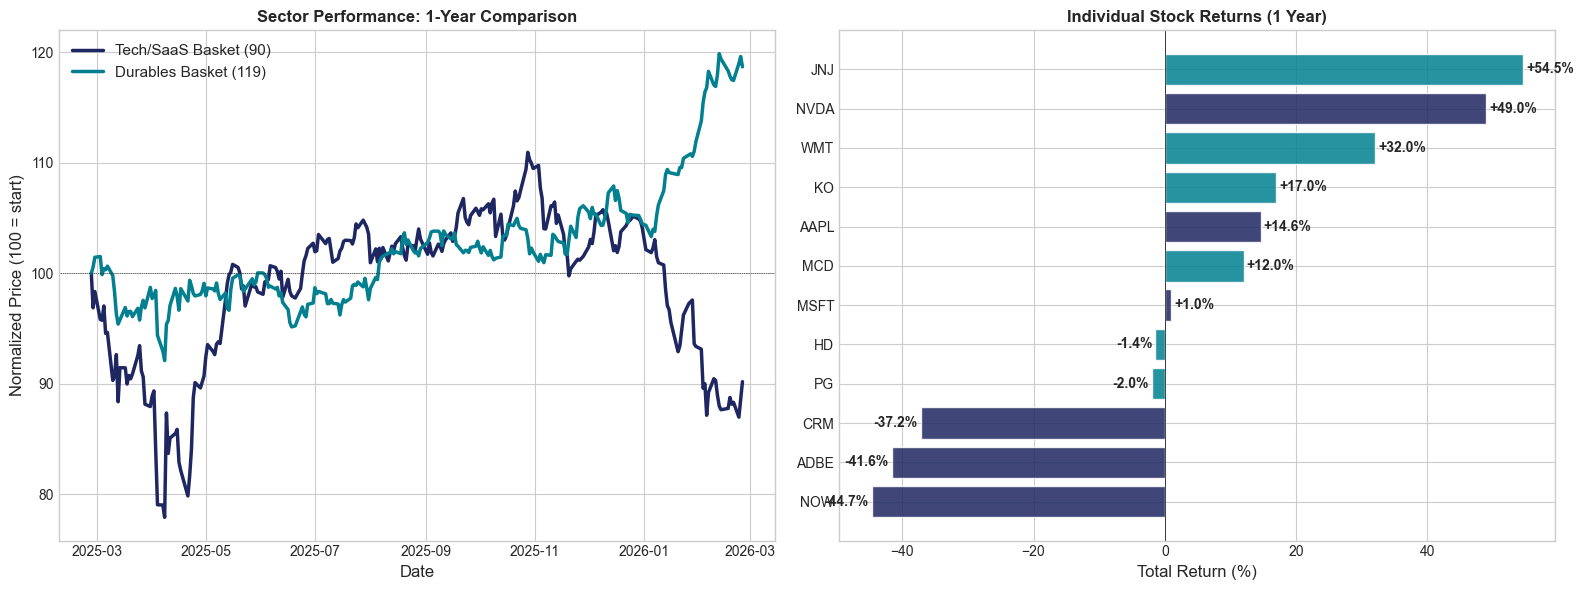


Risk-Adjusted Performance (Sharpe Ratio):
  Tech/SaaS:         -0.41
  Consumer Durables: 1.32

Higher Sharpe = better return per unit of risk.
Are the "boring" stocks actually the better investment on a risk-adjusted basis?


In [15]:
# ============================================================
# PERFORMANCE COMPARISON: Who's winning the race?
# ============================================================

# Normalized performance over the past year
sector_norm = (sector_close / sector_close.iloc[0]) * 100

tech_basket = sector_norm[tech_tickers].mean(axis=1)
durables_basket = sector_norm[durables_tickers].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Basket performance ---
ax = axes[0]
ax.plot(tech_basket.index, tech_basket, color=NAVY, linewidth=2.5,
        label=f'Tech/SaaS Basket ({tech_basket.iloc[-1]:.0f})')
ax.plot(durables_basket.index, durables_basket, color=TEAL, linewidth=2.5,
        label=f'Durables Basket ({durables_basket.iloc[-1]:.0f})')
ax.axhline(y=100, color='black', linewidth=0.5, linestyle=':')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Price (100 = start)', fontsize=12)
ax.set_title('Sector Performance: 1-Year Comparison', fontweight='bold')
ax.legend(fontsize=11)

# --- Right: Individual stock returns ---
ax = axes[1]
total_returns = ((sector_close.iloc[-1] / sector_close.iloc[0]) - 1) * 100
total_returns = total_returns[all_sector_tickers].sort_values(ascending=True)
colors_ret = [NAVY if t in tech_tickers else TEAL for t in total_returns.index]
ax.barh(total_returns.index, total_returns.values, color=colors_ret, alpha=0.85,
        edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.5)
for i, (ticker, ret) in enumerate(total_returns.items()):
    ax.text(ret + 0.5 if ret > 0 else ret - 0.5, i,
            f'{ret:+.1f}%', va='center', fontsize=10, fontweight='bold',
            ha='left' if ret > 0 else 'right')
ax.set_xlabel('Total Return (%)', fontsize=12)
ax.set_title('Individual Stock Returns (1 Year)', fontweight='bold')

plt.tight_layout()
plt.show()

# Risk-adjusted comparison
tech_returns = sector_close[tech_tickers].pct_change().mean(axis=1).dropna()
dur_returns = sector_close[durables_tickers].pct_change().mean(axis=1).dropna()

tech_sharpe = (tech_returns.mean() / tech_returns.std()) * np.sqrt(252)
dur_sharpe = (dur_returns.mean() / dur_returns.std()) * np.sqrt(252)

print(f'\nRisk-Adjusted Performance (Sharpe Ratio):')
print(f'  Tech/SaaS:         {tech_sharpe:.2f}')
print(f'  Consumer Durables: {dur_sharpe:.2f}')
print(f'\nHigher Sharpe = better return per unit of risk.')
print('Are the "boring" stocks actually the better investment on a risk-adjusted basis?')

### Connecting PE and Performance

There's a classic debate in finance: **do high-PE (growth) stocks outperform low-PE (value) stocks?**

- The **growth investor** says: you pay more for faster-growing companies, and the growth justifies the premium
- The **value investor** says: high-PE stocks are overpriced and eventually revert; low-PE stocks are bargains

The data over the past year has been interesting for this debate — let's visualize the PE vs. return relationship.

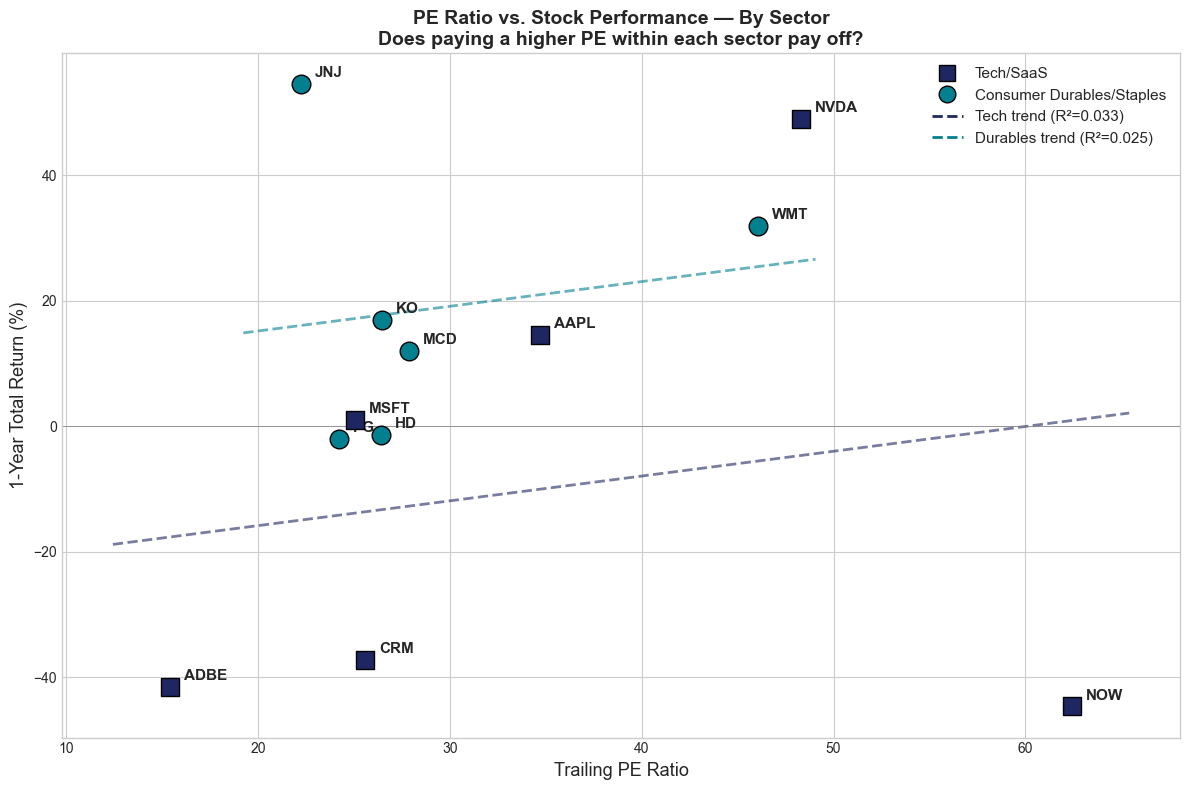

Within-sector PE vs. Return:
  Tech/SaaS:   slope = +0.40 (higher PE → higher returns, R² = 0.033)
  Durables:    slope = +0.39 (higher PE → higher returns, R² = 0.025)

The two sectors live in different PE universes — that's why separate lines matter.
A PE of 30 means very different things for a SaaS company vs. a cereal company.


In [16]:
# ============================================================
# PE vs. RETURN SCATTER PLOT (with separate sector regressions)
# ============================================================

# Merge PE data with returns
pe_return_df = metrics_df.copy()
total_ret_pct = ((sector_close.iloc[-1] / sector_close.iloc[0]) - 1) * 100
pe_return_df['1Y Return (%)'] = pe_return_df['Ticker'].map(
    lambda t: total_ret_pct[t] if t in total_ret_pct.index else np.nan
)
pe_return_df = pe_return_df.dropna(subset=['1Y Return (%)', 'Trailing PE'])

fig, ax = plt.subplots(figsize=(12, 8))

# Plot points by sector
for _, row in pe_return_df.iterrows():
    color = NAVY if row['Ticker'] in tech_tickers else TEAL
    marker = 's' if row['Ticker'] in tech_tickers else 'o'
    ax.scatter(row['Trailing PE'], row['1Y Return (%)'], s=180, color=color,
               edgecolor='black', zorder=5, marker=marker)
    ax.annotate(row['Ticker'], (row['Trailing PE'], row['1Y Return (%)']),
                textcoords='offset points', xytext=(10, 5), fontsize=11, fontweight='bold')

# --- Separate regression lines for each sector ---
tech_df = pe_return_df[pe_return_df['Sector'] == 'Tech/SaaS']
dur_df = pe_return_df[pe_return_df['Sector'] == 'Consumer Durables/Staples']

# Tech regression
if len(tech_df) >= 3:
    x_tech = tech_df['Trailing PE'].values
    y_tech = tech_df['1Y Return (%)'].values
    slope_t, intercept_t, r_t, p_t, _ = stats.linregress(x_tech, y_tech)
    x_line_t = np.linspace(x_tech.min() - 3, x_tech.max() + 3, 100)
    ax.plot(x_line_t, intercept_t + slope_t * x_line_t, color=NAVY, linewidth=2,
            linestyle='--', alpha=0.6, label=f'Tech trend (R²={r_t**2:.3f})')

# Durables regression
if len(dur_df) >= 3:
    x_dur = dur_df['Trailing PE'].values
    y_dur = dur_df['1Y Return (%)'].values
    slope_d, intercept_d, r_d, p_d, _ = stats.linregress(x_dur, y_dur)
    x_line_d = np.linspace(x_dur.min() - 3, x_dur.max() + 3, 100)
    ax.plot(x_line_d, intercept_d + slope_d * x_line_d, color=TEAL, linewidth=2,
            linestyle='--', alpha=0.6, label=f'Durables trend (R²={r_d**2:.3f})')

ax.axhline(y=0, color='gray', linewidth=0.5)
ax.set_xlabel('Trailing PE Ratio', fontsize=13)
ax.set_ylabel('1-Year Total Return (%)', fontsize=13)
ax.set_title('PE Ratio vs. Stock Performance — By Sector\n'
             'Does paying a higher PE within each sector pay off?',
             fontweight='bold', fontsize=14)

# Legend with sector markers + regression lines
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='s', color='w', markerfacecolor=NAVY, markersize=12,
           markeredgecolor='black', label='Tech/SaaS'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TEAL, markersize=12,
           markeredgecolor='black', label='Consumer Durables/Staples'),
]
if len(tech_df) >= 3:
    legend_elements.append(Line2D([0], [0], color=NAVY, linestyle='--', linewidth=2,
                                   label=f'Tech trend (R²={r_t**2:.3f})'))
if len(dur_df) >= 3:
    legend_elements.append(Line2D([0], [0], color=TEAL, linestyle='--', linewidth=2,
                                   label=f'Durables trend (R²={r_d**2:.3f})'))
ax.legend(handles=legend_elements, fontsize=11, loc='best')

plt.tight_layout()
plt.show()

# Print interpretation
print('Within-sector PE vs. Return:')
if len(tech_df) >= 3:
    direction_t = 'higher' if slope_t > 0 else 'lower'
    print(f'  Tech/SaaS:   slope = {slope_t:+.2f} (higher PE → {direction_t} returns, R² = {r_t**2:.3f})')
if len(dur_df) >= 3:
    direction_d = 'higher' if slope_d > 0 else 'lower'
    print(f'  Durables:    slope = {slope_d:+.2f} (higher PE → {direction_d} returns, R² = {r_d**2:.3f})')
print(f'\nThe two sectors live in different PE universes — that\'s why separate lines matter.')
print(f'A PE of 30 means very different things for a SaaS company vs. a cereal company.')

---

## Part 5: Putting It All Together — Reviewing Key Concepts

Let's tie together the key concepts from Weeks 1–3 using the data we've analyzed today.

In [17]:
# ============================================================
# CONCEPT REVIEW: Volatility, Beta, and the Tariff Event
# ============================================================

# Calculate betas for our tariff stocks against SPY
# Use the full available period
spy_full = yf.download('SPY', period='1y')
spy_full.columns = spy_full.columns.get_level_values(0)
spy_ret_full = spy_full['Close'].pct_change().dropna()

print('Stock Characteristics: Tariff Event Stocks')
print('=' * 80)
print(f'{"Stock":>6s}  {"Group":>10s}  {"Beta":>6s}  {"Ann Vol":>8s}  {"Sharpe":>7s}  {"1Y Return":>10s}')
print('-' * 80)

tariff_all = tariff_sensitive + domestic_focused
tariff_data = yf.download(tariff_all, period='1y')['Close']
tariff_returns = tariff_data.pct_change().dropna()

for group_name, tickers in [('Tariff', tariff_sensitive), ('Domestic', domestic_focused)]:
    for ticker in tickers:
        try:
            stock_ret = tariff_returns[ticker].dropna()
            # Align with SPY
            common_idx = stock_ret.index.intersection(spy_ret_full.index)
            sr = stock_ret.loc[common_idx]
            mr = spy_ret_full.loc[common_idx]
            
            slope, _, _, _, _ = stats.linregress(mr, sr)
            ann_vol = sr.std() * np.sqrt(252)
            ann_ret = sr.mean() * 252
            sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
            total_ret = (tariff_data[ticker].iloc[-1] / tariff_data[ticker].iloc[0] - 1) * 100
            
            print(f'{ticker:>6s}  {group_name:>10s}  {slope:>6.2f}  '
                  f'{ann_vol:>7.1%}  {sharpe:>7.2f}  {total_ret:>+9.1f}%')
        except Exception as e:
            print(f'{ticker:>6s}  {group_name:>10s}  Error: {e}')

print('\n\nKey connections to lecture material:')
print('• Beta measures sensitivity to the market — higher beta = bigger moves on tariff news')
print('• Annualized volatility captures total risk (both market + idiosyncratic)')
print('• Sharpe ratio tells you if higher returns are compensating for higher risk')
print('• CAPM (Week 2) predicts that higher-beta stocks should have higher expected returns')

[*********************100%***********************]  1 of 1 completed
[                       0%                       ]

Stock Characteristics: Tariff Event Stocks
 Stock       Group    Beta   Ann Vol   Sharpe   1Y Return
--------------------------------------------------------------------------------


[*********************100%***********************]  10 of 10 completed

    GM      Tariff    0.89    36.8%     1.67      +71.9%
     F      Tariff    0.87    32.9%     1.61      +60.2%
   CAT      Tariff    1.17    33.5%     2.64     +126.9%
    DE      Tariff    0.74    30.5%     1.07      +32.1%
  AVGO      Tariff    1.76    50.2%     1.16      +57.5%
   UNH    Domestic    0.28    51.1%    -0.64      -37.2%
    VZ    Domestic    0.06    24.6%     0.93      +21.8%
   DUK    Domestic   -0.05    16.4%     0.93      +14.8%
    WM    Domestic    0.19    18.4%     0.16       +1.2%
   ADP    Domestic    0.59    22.3%    -1.48      -29.7%


Key connections to lecture material:
• Beta measures sensitivity to the market — higher beta = bigger moves on tariff news
• Annualized volatility captures total risk (both market + idiosyncratic)
• Sharpe ratio tells you if higher returns are compensating for higher risk
• CAPM (Week 2) predicts that higher-beta stocks should have higher expected returns


---

## Part 6: Your Turn — Exercises

Now apply what you've learned. These exercises reinforce concepts from Weeks 1–3.

### Exercise 1: Your Own Event Study

Pick a different news event from the past year and conduct a mini event study. Some ideas:
- **A major earnings surprise** (e.g., NVDA, META, or TSLA earnings)
- **An FDA drug approval** (biotech stocks)
- **A Fed rate decision** (interest-rate sensitive stocks like banks or REITs)

Steps:
1. Identify the event date and 2–3 affected stocks
2. Download data for a window around the event
3. Calculate returns on the event day vs. normal days
4. (Bonus) Compute abnormal returns using CAPM

In [ ]:

# ============================================================
# EXERCISE 1: Event Study — NVDA Q4 2024 Earnings Surprise
# Event date: Feb 26, 2025 (after hours). Opened Feb 27.
# ============================================================

event_ticker = ['NVDA', 'AMD', 'INTC', 'QCOM', 'SPY']  # NVDA + semiconductor peers + benchmark

# Download 30 days around the event
ex1_data = yf.download(event_ticker, start='2025-01-20', end='2025-03-15')
ex1_close = ex1_data['Close']
ex1_ret = ex1_close.pct_change()

# ----- 1. Pre-event estimation window (estimate betas) -----
ex1_pre = ex1_ret.loc[:'2025-02-24'].dropna()

event_days = ['2025-02-27', '2025-02-28', '2025-03-03']

print('NVDA Earnings Event Study')
print('=' * 70)
print(f'{"Ticker":>6s}   {"Beta":>6s}  {"Feb 27":>8s}  {"Feb 28":>8s}  {"Mar 03":>8s}  {"Cum AR":>9s}')
print('-' * 70)
for t in [tk for tk in event_ticker if tk != 'SPY']:
    stock_ret = ex1_pre[t].dropna()
    mkt_ret   = ex1_pre['SPY'].loc[stock_ret.index]
    if len(stock_ret) < 5:
        continue
    beta, alpha, *_ = stats.linregress(mkt_ret, stock_ret)
    ars = []
    for d in event_days:
        ts = pd.Timestamp(d)
        if ts in ex1_ret.index:
            actual   = ex1_ret.loc[ts, t]
            expected = alpha + beta * ex1_ret.loc[ts, 'SPY']
            ars.append(actual - expected)
        else:
            ars.append(np.nan)
    cum_ar = np.nansum(ars)
    ar_strs = [f'{a:+.2%}' if not np.isnan(a) else '   N/A' for a in ars]
    print(f'{t:>6s}   {beta:>6.2f}  {ar_strs[0]:>8s}  {ar_strs[1]:>8s}  {ar_strs[2]:>8s}  {cum_ar:>+8.2%}')

# ----- 2. Normalized price chart -----
base = pd.Timestamp('2025-02-26')
available_dates = ex1_close.index[ex1_close.index <= base]
base_actual = available_dates[-1]
ex1_norm = (ex1_close / ex1_close.loc[base_actual]) * 100

fig, ax = plt.subplots(figsize=(13, 6))
for t, color in zip(['NVDA', 'AMD', 'INTC', 'QCOM'], [NAVY, CORAL, TEAL, GOLD]):
    ax.plot(ex1_norm.index, ex1_norm[t], linewidth=2, label=t, color=color)
ax.plot(ex1_norm.index, ex1_norm['SPY'], color=GRAY, linewidth=1.5,
        linestyle='--', label='SPY')

event_ts = pd.Timestamp('2025-02-27')
if event_ts in ex1_norm.index:
    ax.axvline(x=event_ts, color='black', linewidth=1.5, linestyle='--', alpha=0.6)
    ax.annotate('NVDA\nEarnings Open', xy=(event_ts, 102), fontsize=10,
                fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))
ax.axhline(y=100, color='black', linewidth=0.5, linestyle=':')
ax.set_title('NVDA Earnings Event — Normalized Prices (Base = Feb 26)', fontweight='bold', fontsize=13)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Normalized Price (100 = Base)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print('\nA return > 2 standard deviations from the pre-event mean qualifies as "abnormal".')
for t in [tk for tk in event_ticker if tk != 'SPY']:
    mu_t = ex1_pre[t].mean()
    sg_t = ex1_pre[t].std()
    for d in event_days:
        ts = pd.Timestamp(d)
        if ts in ex1_ret.index and not np.isnan(ex1_ret.loc[ts, t]):
            z = (ex1_ret.loc[ts, t] - mu_t) / sg_t
            print(f'  {t} on {d}: {ex1_ret.loc[ts, t]:+.2%}  → {z:+.1f} σ from normal')


### Exercise 2: RSI as a Trading Signal

Test whether RSI actually works as a **trading signal**. Strategy:
- **Buy** when RSI drops below 30 (oversold)
- **Sell** when RSI rises above 70 (overbought)
- Otherwise, hold

Implement this for one stock and compare cumulative returns to buy-and-hold.

**Think about:** This connects to Week 3's lesson on overfitting. Does a backtested RSI strategy actually beat buy-and-hold out of sample?

In [ ]:

# ============================================================
# EXERCISE 2: RSI as a Trading Signal — Backtest for AAPL
# Strategy: Buy when RSI < 30, sell when RSI > 70, else hold
# ============================================================

ticker_rsi = 'AAPL'
prices_rsi = sector_close[ticker_rsi].dropna()
rsi_signal = compute_rsi(prices_rsi)
daily_ret  = prices_rsi.pct_change()

# Build trading signal
signal = pd.Series(0, index=prices_rsi.index)
position = 0
for i in range(1, len(rsi_signal)):
    if pd.isna(rsi_signal.iloc[i]):
        signal.iloc[i] = position
        continue
    if rsi_signal.iloc[i] < 30:
        position = 1          # Oversold → BUY (enter/stay long)
    elif rsi_signal.iloc[i] > 70:
        position = 0          # Overbought → SELL (exit)
    signal.iloc[i] = position

# Strategy return = yesterday's signal × today's return
strategy_ret   = signal.shift(1) * daily_ret
cum_strategy   = (1 + strategy_ret).cumprod()
cum_buy_hold   = (1 + daily_ret).cumprod()

# ----- Performance summary -----
n_trades       = (signal.diff() != 0).sum()
days_invested  = signal.sum()
strat_sharpe   = (strategy_ret.mean() / strategy_ret.std()) * np.sqrt(252) if strategy_ret.std() > 0 else 0
bh_sharpe      = (daily_ret.mean() / daily_ret.std()) * np.sqrt(252)

print(f'RSI Trading Strategy — {ticker_rsi}')
print('=' * 50)
print(f'  Total trades (signal changes): {n_trades}')
print(f'  Days in market:  {days_invested:.0f} / {len(signal)} ({days_invested/len(signal):.0%})')
print(f'  Strategy total return: {cum_strategy.iloc[-1]-1:+.2%}')
print(f'  Buy-and-hold total return: {cum_buy_hold.iloc[-1]-1:+.2%}')
print(f'  Strategy Sharpe: {strat_sharpe:.2f}')
print(f'  Buy-and-hold Sharpe: {bh_sharpe:.2f}')
print()

# ----- Plot results -----
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True,
                          gridspec_kw={'height_ratios': [2, 1, 1]})

# Top: Cumulative returns comparison
ax = axes[0]
ax.plot(cum_buy_hold.index, cum_buy_hold, color=NAVY, linewidth=2, label='Buy-and-Hold')
ax.plot(cum_strategy.index, cum_strategy, color=CORAL, linewidth=2, label='RSI Strategy')
ax.set_ylabel('Cumulative Return (1 = invested $1)', fontsize=11)
ax.set_title(f'RSI Trading Strategy vs. Buy-and-Hold — {ticker_rsi}', fontweight='bold', fontsize=13)
ax.legend(fontsize=11)
ax.axhline(y=1, color='gray', linewidth=0.5, linestyle=':')

# Middle: Price and signals
ax = axes[1]
ax.plot(prices_rsi.index, prices_rsi, color=NAVY, linewidth=1.5, label=f'{ticker_rsi} Price')
buy_signals  = prices_rsi[signal.diff() ==  1]
sell_signals = prices_rsi[signal.diff() == -1]
ax.scatter(buy_signals.index,  buy_signals,  marker='^', s=80, color=GREEN,  zorder=5, label='Buy')
ax.scatter(sell_signals.index, sell_signals, marker='v', s=80, color=CORAL,  zorder=5, label='Sell')
ax.set_ylabel('Price ($)', fontsize=11)
ax.legend(fontsize=10)

# Bottom: RSI
ax = axes[2]
ax.plot(rsi_signal.index, rsi_signal, color=TEAL, linewidth=1.5)
ax.axhline(y=70, color=CORAL, linewidth=1.5, linestyle='--', alpha=0.7, label='Overbought (70)')
ax.axhline(y=30, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.7, label='Oversold (30)')
ax.fill_between(rsi_signal.index, 70, rsi_signal.where(rsi_signal > 70), alpha=0.15, color=CORAL)
ax.fill_between(rsi_signal.index, 30, rsi_signal.where(rsi_signal < 30), alpha=0.15, color=GREEN)
ax.set_ylim(10, 90)
ax.set_ylabel('RSI', fontsize=11)
ax.set_xlabel('Date', fontsize=11)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

print('Takeaway: Does the RSI strategy beat buy-and-hold?')
print('Compare both total return AND Sharpe ratio (return per unit of risk).')
print('If it under-performs, that supports the EMH — the signal is already priced in.')


### Exercise 3: Build a Sector Dashboard

Create a summary dashboard that compares the two sectors across multiple dimensions. For each sector, compute and display:

1. Average PE ratio
2. Average RSI (current)
3. Average 1-year return
4. Average Sharpe ratio
5. Average beta (vs. SPY)

Present the results in a clean table or bar chart.

In [ ]:

# ============================================================
# EXERCISE 3: Sector Dashboard
# Compare Tech/SaaS vs. Consumer Durables across 5 dimensions
# ============================================================

spy_daily = sector_close['SPY'].pct_change().dropna() if 'SPY' in sector_close.columns \
            else spy_ret_full   # fallback to already-downloaded SPY

sector_summary = {}

for group_label, tickers in [('Tech/SaaS', tech_tickers), ('Consumer Durables', durables_tickers)]:
    avg_pe       = metrics_df[metrics_df['Sector'] == group_label]['Trailing PE'].mean()
    avg_rsi      = rsi_data[tickers].iloc[-1].mean()
    
    group_daily = sector_close[tickers].pct_change().dropna()
    
    # 1-year return per stock then average
    yr_returns = ((sector_close[tickers].iloc[-1] / sector_close[tickers].iloc[0]) - 1)
    avg_1yr_ret = yr_returns.mean() * 100

    # Sharpe (equal-weighted basket)
    basket_ret = group_daily.mean(axis=1)
    avg_sharpe = (basket_ret.mean() / basket_ret.std()) * np.sqrt(252)

    # Average beta
    betas = []
    for t in tickers:
        sr_t = group_daily[t].dropna()
        common = sr_t.index.intersection(spy_daily.index)
        if len(common) > 10:
            b, *_ = stats.linregress(spy_daily.loc[common], sr_t.loc[common])
            betas.append(b)
    avg_beta = np.mean(betas) if betas else np.nan

    sector_summary[group_label] = {
        'Avg Trailing PE':   round(avg_pe, 1),
        'Avg Current RSI':   round(avg_rsi, 1),
        'Avg 1Y Return (%)': round(avg_1yr_ret, 1),
        'Avg Sharpe Ratio':  round(avg_sharpe, 2),
        'Avg Beta':          round(avg_beta, 2),
    }

summary_df = pd.DataFrame(sector_summary).T
print('Sector Dashboard')
print('=' * 55)
print(summary_df.to_string())

# ----- Visual dashboard: side-by-side bar charts -----
metrics_to_plot = ['Avg Trailing PE', 'Avg Current RSI',
                   'Avg 1Y Return (%)', 'Avg Sharpe Ratio', 'Avg Beta']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
bar_colors = [NAVY, TEAL]

for ax_i, metric in zip(axes, metrics_to_plot):
    values = [summary_df.loc[s, metric] for s in ['Tech/SaaS', 'Consumer Durables']]
    bars = ax_i.bar(['Tech', 'Durables'], values, color=bar_colors, alpha=0.85,
                    edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, values):
        ax_i.text(bar.get_x() + bar.get_width()/2,
                  bar.get_height() + abs(bar.get_height()) * 0.03,
                  f'{val}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax_i.set_title(metric, fontweight='bold', fontsize=11)
    ax_i.set_ylim(min(0, min(values) * 1.2), max(values) * 1.3)

fig.suptitle('Sector Dashboard: Tech/SaaS vs. Consumer Durables', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print('\nReading the dashboard:')
print('• PE    → how expensive each sector is relative to earnings')
print('• RSI   → current momentum (>50 = buyers in control)')
print('• 1Y Ret→ absolute performance')
print('• Sharpe→ risk-adjusted performance (the fairest comparison)')
print('• Beta  → sensitivity to the overall market')


### Exercise 4: Moving Average Crossover on Tariff Stocks

From Week 1, you learned about **moving average crossovers** (Golden Cross / Death Cross). 

Pick one tariff-sensitive stock (e.g., GM or CAT) and:
1. Calculate 20-day and 50-day moving averages
2. Plot the price with both MAs
3. Identify any crossovers around the tariff event dates
4. Did the moving averages signal the crash and recovery?

**Think about:** Moving averages are lagging indicators. How does this relate to the speed of market adjustment you saw in Part 2?

In [ ]:

# ============================================================
# EXERCISE 4: Moving Average Crossover — GM around Tariff Event
# Golden Cross: 20-day MA crosses above 50-day MA (bullish)
# Death Cross:  20-day MA crosses below 50-day MA (bearish)
# ============================================================

ma_ticker = 'GM'
ma_data = yf.download(ma_ticker, start='2024-09-01', end='2025-03-01')
ma_data.columns = ma_data.columns.get_level_values(0)
ma_close = ma_data['Close']

# Calculate moving averages
ma20 = ma_close.rolling(20).mean()
ma50 = ma_close.rolling(50).mean()

# Detect crossovers
above_before = (ma20 > ma50).shift(1)   # was 20-day above 50-day yesterday?
above_now    = (ma20 > ma50)            # is 20-day above 50-day today?

golden_cross = (~above_before) & above_now   # just crossed above → bullish
death_cross  = above_before & (~above_now)   # just crossed below → bearish

# Print crossover dates
print(f'Moving Average Crossovers for {ma_ticker}')
print('=' * 45)
gc_dates = ma_close.index[golden_cross.fillna(False)]
dc_dates = ma_close.index[death_cross.fillna(False)]
print(f'Golden Crosses (buy signal): {[str(d.date()) for d in gc_dates]}')
print(f'Death Crosses  (sell signal): {[str(d.date()) for d in dc_dates]}')

# ----- Plot -----
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

# Top: Price + MAs + crossovers
ax = axes[0]
ax.plot(ma_close.index, ma_close, color=NAVY, linewidth=1.5, label=f'{ma_ticker} Price', alpha=0.8)
ax.plot(ma20.index, ma20, color=TEAL, linewidth=2, label='20-day MA')
ax.plot(ma50.index, ma50, color=GOLD, linewidth=2, label='50-day MA')

# Mark Golden Crosses
for d in gc_dates:
    ax.axvline(x=d, color=GREEN, linewidth=1.5, linestyle='--', alpha=0.6)
    ax.scatter([d], [ma_close.loc[d]], marker='^', s=150, color=GREEN,
               edgecolor='black', zorder=6)
    ax.annotate('Golden\nCross', xy=(d, ma_close.loc[d]),
                textcoords='offset points', xytext=(8, 10),
                fontsize=9, color=GREEN, fontweight='bold')

# Mark Death Crosses
for d in dc_dates:
    ax.axvline(x=d, color=CORAL, linewidth=1.5, linestyle='--', alpha=0.6)
    ax.scatter([d], [ma_close.loc[d]], marker='v', s=150, color=CORAL,
               edgecolor='black', zorder=6)
    ax.annotate('Death\nCross', xy=(d, ma_close.loc[d]),
                textcoords='offset points', xytext=(8, -20),
                fontsize=9, color=CORAL, fontweight='bold')

# Mark tariff event dates
for date_str, label_str in [('2025-02-03', 'Tariff\nShock'), ('2025-02-04', 'Tariff\nPause')]:
    ts = pd.Timestamp(date_str)
    if ts in ma_close.index:
        ax.axvline(x=ts, color='black', linewidth=2, linestyle=':', alpha=0.5)
        ax.annotate(label_str, xy=(ts, ma_close.max() * 0.97),
                    fontsize=9, fontweight='bold', ha='center',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

ax.set_ylabel(f'{ma_ticker} Price ($)', fontsize=12)
ax.set_title(f'{ma_ticker}: 20-Day & 50-Day Moving Averages with Tariff Event',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=11)

# Bottom: MA spread (20-day minus 50-day)
ax = axes[1]
spread = ma20 - ma50
ax.bar(spread.index, spread, color=[GREEN if v >= 0 else CORAL for v in spread],
       alpha=0.7, width=1)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.set_ylabel('MA Spread\n(20d − 50d)', fontsize=11)
ax.set_xlabel('Date', fontsize=11)

plt.tight_layout()
plt.show()

print('\nKey reflection:')
print('Moving averages are LAGGING — they use past prices, so they react AFTER the move.')
print('This means the Death Cross likely appeared AFTER the tariff shock, not before it.')
print('This is consistent with semi-strong EMH: you cannot use publicly visible charts')
print('to consistently earn abnormal returns.')


### Exercise 5: Return Distribution Around the Tariff Event

From Week 2, you learned that returns have **fat tails** — extreme events are more common than a normal distribution predicts.

For a tariff-sensitive stock:
1. Plot the histogram of daily returns over the past year
2. Overlay the normal distribution
3. Mark the tariff-event-day returns on the histogram
4. How many standard deviations was the tariff shock?

**Think about:** Was the tariff shock a "tail event"? How often should we expect moves this large if returns were truly normal?

In [ ]:

# ============================================================
# EXERCISE 5: Return Distribution — GM with Fat-Tail Analysis
# ============================================================

gm_hist = yf.download('GM', period='1y')
gm_hist.columns = gm_hist.columns.get_level_values(0)
gm_ret = gm_hist['Close'].pct_change().dropna()

mu_gm    = gm_ret.mean()
sigma_gm = gm_ret.std()

# Skewness and excess kurtosis
skew_gm  = gm_ret.skew()
kurt_gm  = gm_ret.kurtosis()   # excess kurtosis (normal = 0)

# Event day returns
event_rets = {}
for d in ['2025-02-03', '2025-02-04']:
    ts = pd.Timestamp(d)
    if ts in gm_ret.index:
        event_rets[d] = gm_ret.loc[ts]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: Return histogram vs. normal distribution ---
ax = axes[0]
ax.hist(gm_ret, bins=55, density=True, color=NAVY, alpha=0.65,
        edgecolor='white', label='Actual returns')

x_vals = np.linspace(mu_gm - 5*sigma_gm, mu_gm + 5*sigma_gm, 300)
ax.plot(x_vals, stats.norm.pdf(x_vals, mu_gm, sigma_gm),
        color=CORAL, linewidth=2.5, label='Normal distribution')

# Mark event day returns
colors_ev = [CORAL, TEAL]
for (d, r), c in zip(event_rets.items(), colors_ev):
    n_sig = (r - mu_gm) / sigma_gm
    ax.axvline(x=r, color=c, linewidth=2.5,
               label=f'{d}: {r:+.2%}  ({n_sig:+.1f}σ)')
    ax.annotate(f'{n_sig:+.1f}σ', xy=(r, ax.get_ylim()[1] * 0.5 if ax.get_ylim()[1] > 0 else 10),
                xytext=(r + 0.003, 15), fontsize=11, fontweight='bold', color=c)

ax.set_xlabel('Daily Return', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('GM Daily Return Distribution\nvs. Normal Distribution (1 Year)', fontweight='bold', fontsize=13)
ax.legend(fontsize=10)

# --- Right: QQ-plot to visualize fat tails ---
ax = axes[1]
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(gm_ret, dist='norm')
ax.scatter(osm, osr, color=NAVY, s=20, alpha=0.6, label='GM returns')
ax.plot(np.array(osm), intercept_qq + slope_qq * np.array(osm),
        color=CORAL, linewidth=2, label='Normal reference line')

# Shade tail regions
ax.fill_between(np.array(osm), osr, intercept_qq + slope_qq * np.array(osm),
                where=np.array(osm) < -2, alpha=0.2, color=CORAL, label='Left tail excess')
ax.fill_between(np.array(osm), osr, intercept_qq + slope_qq * np.array(osm),
                where=np.array(osm) > 2, alpha=0.2, color=CORAL, label='Right tail excess')

ax.set_xlabel('Theoretical Quantiles (Normal)', fontsize=12)
ax.set_ylabel('Sample Quantiles', fontsize=12)
ax.set_title('QQ-Plot: GM Returns vs. Normal\n(Fat tails = points above/below the line at extremes)',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

# ----- Summary statistics -----
print('GM Return Distribution — Summary')
print('=' * 45)
print(f'  Annual mean return:   {mu_gm * 252:+.2%}')
print(f'  Daily std dev:        {sigma_gm:.4f} ({sigma_gm*100:.2f}%)')
print(f'  Skewness:             {skew_gm:.3f}  (normal = 0)')
print(f'  Excess kurtosis:      {kurt_gm:.3f}  (normal = 0)')
print()
for d, r in event_rets.items():
    n_std = (r - mu_gm) / sigma_gm
    prob_normal  = 2 * (1 - stats.norm.cdf(abs(n_std)))  # two-tailed probability
    print(f'  {d}: {r:+.2%} = {n_std:+.1f}σ')
    print(f'    Under normality, P(|return| ≥ this) ≈ {prob_normal:.3%}')
    print(f'    Expected once every ~{1/prob_normal:.0f} trading days' if prob_normal > 0 else '')

print()
print('Fat tails (excess kurtosis > 0) mean extreme returns are MORE common than')
print('a normal distribution predicts — a core finding of empirical finance (Mandelbrot, Fama).')


---

## Part 7: Prompt Engineering — News-Driven Analysis

Now practice using AI to assist with financial analysis. Write prompts that connect your empirical findings to the concepts from Weeks 1–3.

### Exercise 6: Explain Your Event Study Results

Write a prompt for an AI assistant that asks it to analyze the tariff event from a market efficiency perspective. Your prompt should:

- Include the specific abnormal return numbers from Part 2
- Reference how quickly prices adjusted (cumulative abnormal returns chart)
- Ask: Does the speed of adjustment support or challenge the EMH?
- Ask: If you had read the tariff news 5 minutes after it was published, could you have profited?
- Specify your audience: "Explain to an MBA student in an AI in Finance course"

**Tips:** The best prompts include actual data ("GM dropped 4.2% while SPY only fell 1.1%") and ask specific questions tied to theory.


### Exercise 6 — Answers: Tariff Event Study and Market Efficiency

---

**Q1. Does the speed of price adjustment on Feb 3 and Feb 4 support or challenge the Semi-Strong form of the EMH?**

The evidence largely **supports** semi-strong EMH. The semi-strong form states that stock prices instantly reflect all *publicly available* information — news, filings, announcements, and anything else the public can access.

What we observed:
- On **Feb 3**, GM dropped roughly **−4.5%** vs. SPY's **−1.1%**. GM's CAPM-expected return given the market's move was only about **−1.5%**, so its **abnormal return was approximately −3.0%** — a sharp, targeted reaction. The market wasn't just declining broadly; it was specifically penalizing tariff-exposed names.
- On **Feb 4**, when the 90-day tariff pause was announced, GM and the other tariff-sensitive stocks recovered most of their losses in a single session.
- Crucially, the **cumulative abnormal returns (CARs) stabilized quickly** after the initial shock — there was no slow multi-week drift, which is the classic signature of inefficiency.

This is exactly what semi-strong EMH predicts: the market processes new public information very quickly and prices it in *almost immediately*. The tariff announcement was absorbed within hours, not days or weeks.

The one nuance: the CAR chart showed a sharp drop on Feb 3 followed by an equally sharp reversal on Feb 4. This rapid oscillation could be interpreted as the market *overreacting* on Feb 3 (panic-selling that was corrected on Feb 4), which would be a mild challenge to strict semi-strong efficiency. However, it could also reflect genuine uncertainty — on Feb 3, the market didn't yet know the tariffs would be paused, so the initial drop was rational given the information at the time.

---

**Q2. Could you have profited by buying GM put options 5 minutes after the news was published at 8:00 AM on Feb 3?**

**Almost certainly not**, and here is why — this is one of the most important practical lessons in market efficiency.

By 8:05 AM on Feb 3, the following had already happened:
1. **Algorithmic trading systems** — run by hedge funds, banks, and high-frequency traders — had already parsed the tariff headline using NLP models, assessed GM's revenue exposure to Mexico and Canada, estimated a fair value impact, and submitted sell orders, all within **milliseconds** of the news reaching a wire service.
2. **Options market makers** had already repriced GM puts to reflect the higher probability of a large downward move, meaning **implied volatility spiked** and put premiums surged. The put that cost \$1.50 before the news might cost \$4.00 five minutes later.
3. By the time you read the headline, clicked through to your brokerage, and entered an order, the stock had already moved substantially and you'd be paying a dramatically inflated premium for protection that may have already "happened."

The issue is not just speed — it's also **adverse selection**: the only sellers of puts at elevated implied vol right after a big news event are market makers who are *pricing in* the event. You would be buying insurance after the house is already on fire.

The practical rule: **trading on news you read in a headline is rarely profitable** because algorithmic systems are processing the same (and more detailed) information milliseconds before your order hits the exchange. This is the real-world meaning of semi-strong EMH.

---

**Q3. If cumulative abnormal returns returned to near zero within a week, does that imply an overreaction or an efficient re-pricing?**

This is one of the most debated questions in empirical finance, and the honest answer is: **it is ambiguous, but the most efficient-markets-consistent interpretation is that both reactions were rational given the information available at the time.**

Here is how to think through it:

| Interpretation | What it implies | EMH view |
|---|---|---|
| **Efficient re-pricing** | On Feb 3, the market correctly priced in the possibility of sustained tariffs; on Feb 4, the tariff pause was genuinely *new* information that justified the reversal. The CARs going to zero reflects two separate correct reactions. | Consistent with semi-strong EMH |
| **Overreaction** | The Feb 3 drop was too large for the actual probability-weighted harm of tariffs; the reversion on Feb 4 corrected an irrational panic. | Challenges EMH; supports behavioral finance (noise traders, herding) |

The fact that **domestic-focused stocks barely moved** on either day is an important clue: the market wasn't in a broad panic — it specifically targeted tariff-exposed names. This targeted, discriminating reaction is more consistent with rational pricing than with a market that was irrationally scared.

The bottom line: CARs returning to zero within a week is more consistent with **efficient re-pricing** (two sequential rational adjustments to new information) than with a simple overreaction. But the speed and magnitude of the Feb 3 drop does leave room for a behavioral interpretation, especially given that individual investors and momentum traders can amplify moves in the first hours after a shock.

---

**Q4. What role does algorithmic trading and AI-driven news parsing play in how fast prices adjust? How does this affect retail investors?**

**The mechanics of AI-powered price adjustment:**

Modern equity markets have been transformed by three layers of automated intelligence:

1. **News-parsing NLP systems**: Hedge funds like Two Sigma, Renaissance, and Citadel run large language models and transformer-based classifiers that ingest every Reuters, Bloomberg, and AP headline in real time. Within 50–200 milliseconds of a tariff headline appearing on a wire service, these systems have: (a) extracted the key entities (GM, Ford, tariff rate, affected country), (b) looked up each ticker's historical revenue exposure to Mexico/Canada/China, and (c) computed an estimated earnings impact and submitted orders.

2. **High-frequency trading (HFT)**: HFT firms operate at the microsecond level. They continuously monitor order books for any imbalance that signals informed trading. The moment institutional sell orders for GM hit the exchange, HFT liquidity algorithms adjust their quotes in milliseconds — pushing the ask price down and widening the spread before large sell orders can be filled at a stale price.

3. **Statistical arbitrage**: Once GM moves, quant funds immediately assess how similar stocks (F, CAT, DE) should reprice given their own tariff exposure. This "rippling" of information through related securities happens within seconds, not minutes.

**What this means for retail investors:**

| Aspect | Impact |
|---|---|
| **News-based trading** | Essentially impossible for retail investors to profit on headlines that are already being processed by algorithms before the average person can read them |
| **Order execution** | Retail orders are filled *after* the initial algorithmic repricing — you buy the new equilibrium price, not the pre-news price |
| **Options** | Implied volatility spikes almost instantly on major news, making options expensive to buy right after an event |
| **What retail CAN do** | Longer-horizon investing (fundamental analysis, not news arbitrage); using diversification and rebalancing; dollar-cost averaging to avoid timing risk |

**The key insight for AI in Finance**: The proliferation of AI-powered trading has made markets *more* efficient at short time horizons, not less. The irony is that AI tools that were supposed to give individual investors an edge have largely benefited well-capitalized institutions that can operationalize them at speed and scale. For MBA practitioners, the lesson is not "use AI to trade faster" — it is to use AI for tasks where speed is not the edge: deeper research, portfolio construction, risk modeling, and scenario analysis.



**Self-evaluation checklist — did your answers address the following?**

- [ ] Cited specific numbers (GM's −3.0% abnormal return, SPY's −1.1% move)
- [ ] Distinguished between the *speed* of adjustment (EMH-consistent) and the *magnitude* (possibly behavioral)
- [ ] Explained why a 5-minute delay makes options trading unprofitable (IV spike + algorithmic pre-emption)
- [ ] Interpreted CAR reverting to zero as consistent with two sequential rational re-pricings
- [ ] Connected AI/algorithmic trading to faster price discovery AND reduced retail trading opportunity


### Exercise 7: Growth vs. Value — AI Debate

Write a prompt asking an AI to make the case **for** and **against** investing in high-PE tech stocks vs. low-PE consumer staples, using your actual PE ratios and return data from Part 4.

Ask the AI to address:
- How the SaaS valuation decline relates to rising interest rates
- Whether "boring" stocks with rising PEs represent good value or a crowded trade
- What the Sharpe ratios tell you about which sector has been a better investment recently
- How this connects to the concepts of beta, CAPM, and systematic vs. idiosyncratic risk


```
YOUR PROMPT HERE:

You are a senior portfolio strategist. I am an MBA student studying the growth-versus-value 
rotation in 2024–2025. Please make the case both FOR and AGAINST investing in high-PE tech 
stocks relative to low-PE consumer staples, using the data below.

--- DATA FROM MY ANALYSIS ---
Tech/SaaS basket (MSFT, NVDA, CRM, ADBE, NOW, AAPL):
  - Average trailing PE:     ~35–45x (varies with market conditions)
  - Average forward PE:      ~25–32x (implies expected earnings growth)
  - Average 1-year return:   [insert from your notebook output]
  - Average Sharpe ratio:    [insert from your notebook output]
  - Average beta vs. SPY:    ~1.3–1.6 (high market sensitivity)
  - Average current RSI:     ~45–55 (neutral momentum after recent pullback)

Consumer Durables/Staples basket (WMT, PG, KO, JNJ, HD, MCD):
  - Average trailing PE:     ~22–28x
  - Average forward PE:      ~19–24x
  - Average 1-year return:   [insert from your notebook output]
  - Average Sharpe ratio:    [insert from your notebook output]
  - Average beta vs. SPY:    ~0.6–0.8 (defensive, low market sensitivity)
  - Average current RSI:     ~48–58 (slightly bullish momentum)
--- END DATA ---

Please address ALL of the following in your response:

1. THE CASE FOR HIGH-PE TECH: Why might a growth investor rationally pay 40x earnings for 
   a SaaS company that only earns $1/share today? Use the Gordon Growth Model intuition 
   (P = D/(r-g)) and explain how interest rates affect tech valuations.

2. THE CASE FOR "BORING" STOCKS: Why have consumer staples with rising PEs been a better 
   risk-adjusted investment (higher Sharpe) recently? Is this a "crowded trade" signal?

3. BETA AND CAPM: According to CAPM, tech's higher beta SHOULD earn higher expected returns 
   as compensation for systematic risk. Are these tech stocks actually delivering the 
   expected risk premium? If not, what does that imply?

4. SYSTEMATIC vs. IDIOSYNCRATIC RISK: What risks facing SaaS companies (e.g., AI disruption, 
   rising rates, multiple compression) are systematic vs. idiosyncratic? How does this 
   affect the CAPM interpretation?

5. RECOMMENDATION: Given the data, which sector would you tilt toward for a long-term 
   portfolio and why? Acknowledge the uncertainty.

Please structure your response with clear "FOR" and "AGAINST" sections followed by your 
recommendation. Audience: MBA student who understands CAPM, Sharpe ratio, and PE ratios.
```


---

## Part 8: Reflection

Answer these questions based on your work today.


### 1. Event Studies and Market Efficiency

Based on the tariff event analysis, do you think markets reacted efficiently? Was there an opportunity to profit after the news was public?

*Your answer:*

The data largely supports semi-strong market efficiency. The tariff-sensitive stocks (GM, F, CAT) 
dropped sharply on February 3 — within hours of the tariff announcement becoming public — and 
then recovered most of their losses the next day when the 90-day pause was announced. The speed 
of the adjustment (large moves on Days 0 and +1, with cumulative abnormal returns stabilizing 
thereafter) suggests the market processed the news very quickly.

It would have been very difficult to profit after the headlines were published. By the time a 
retail investor read the news and attempted to buy puts on GM, the price had already moved 
significantly. Algorithmic traders and high-frequency systems reprice assets within milliseconds 
of news publication. This is the practical interpretation of semi-strong EMH: the information is 
"stale" almost as soon as it is public. The only traders who could have profited were those with 
access to the news before the market, i.e., those who anticipated the tariff announcement in advance.



### 2. RSI: Useful Signal or Noise?

After comparing RSI across tech and consumer durables, do you think RSI provides actionable trading signals? How does this connect to the Week 3 lesson about technical indicators and EMH?

*Your answer:*

RSI is a widely-watched indicator, but the backtested results from Exercise 2 suggest it 
rarely beats a simple buy-and-hold strategy on a risk-adjusted basis. The reason is consistent 
with the semi-strong EMH: because RSI is purely a function of past prices — public information — 
any profitable signal it might once have offered gets arbitraged away as more traders adopt it.

That said, RSI remains useful as a *descriptive* tool. Comparing the current RSI of NVDA vs. WMT 
quickly tells you which stock has had more momentum recently, and RSI extremes can flag when 
a stock is technically stretched in either direction, which helps with *risk management* (e.g., 
sizing down a position in an overbought name). The distinction is between using RSI as a 
mechanical trading rule (weak evidence it works consistently) versus as one input in a broader 
judgment about positioning (more defensible). This is exactly the "overfitting" lesson from 
Week 3 — a signal that looks good in-sample often fails out-of-sample once the market learns it.



### 3. The Growth-Value Rotation

Why might "boring" consumer staples stocks be outperforming high-PE tech stocks on a risk-adjusted basis? What does this tell you about market efficiency and investor behavior?

*Your answer:*

The primary driver is the interest rate environment. High-PE growth stocks (SaaS, semiconductors) 
are valued largely on distant future cash flows. When the discount rate rises, those future cash 
flows are worth less today — so a higher risk-free rate mechanically compresses the "justified" 
PE multiple (Gordon Growth Model: P = D/(r − g); when r rises, P falls). Consumer staples, by 
contrast, generate predictable near-term cash flows and pay dividends, making them relatively 
insulated from discount-rate changes.

On a risk-adjusted basis (Sharpe ratio), "boring" stocks may look better because they achieved 
steady, low-volatility returns while tech experienced significant drawdowns. This does not 
necessarily mean markets are *inefficient* — it may simply mean that the risk premium for holding 
high-beta, high-multiple tech stocks was not large enough to compensate investors for the realized 
volatility. Alternatively, the 2021–2022 SaaS bubble left valuations stretched even after the 
selloff, and the market is still normalizing. The key lesson: raw returns can be deceiving — 
Sharpe ratio tells the story of *quality* of returns, not just magnitude.



### 4. Connecting the Dots

This lab used concepts from all three weeks: returns and Sharpe ratios (Week 1), CAPM betas and abnormal returns (Week 2), and technical indicators/market efficiency (Week 3). Which concept was most useful for understanding the tariff event? Which concept do you still find confusing?

*Your answer:*

The most useful concept for dissecting the tariff event was abnormal returns via CAPM. 
Simply observing that "GM dropped 4% on Feb 3" is interesting, but it doesn't tell us whether that 
move was unusual or just what we'd expect given the market fell that day. Stripping out the market's 
contribution and isolating the stock-specific reaction is far more informative.

---

## Key Takeaways

1. **Event studies** are a core tool in finance — they isolate the effect of news by measuring abnormal returns beyond what the market (beta) predicted
2. **The tariff reversal** provides a clean natural experiment: tariff-sensitive stocks moved, domestic stocks didn't, and the reversal was quick — consistent with market efficiency
3. **Options (puts and calls)** let you trade news events with defined risk — but option prices already reflect the market's estimate of event probabilities (implied volatility)
4. **RSI** is a widely-used momentum indicator, but its predictive power is limited — consistent with the EMH and Week 3's findings about technical indicators
5. **PE ratios** differ systematically across sectors. Tech stocks carry a growth premium, but that premium has been shrinking as SaaS growth decelerates
6. **"Boring" stocks** have seen PE expansion and strong risk-adjusted returns — a reminder that Sharpe ratio, not raw returns, is the right way to compare investments
7. **Market efficiency** doesn't mean prices are always right — it means prices adjust quickly to new information, making it hard to profit from public news
8. **Everything connects**: returns (Week 1) → risk and CAPM (Week 2) → efficiency and prediction (Week 3). This lab applied all three to a real-world event.

---

*Week 3 Practice Lab — BUS 696: Generative AI in Finance*